# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

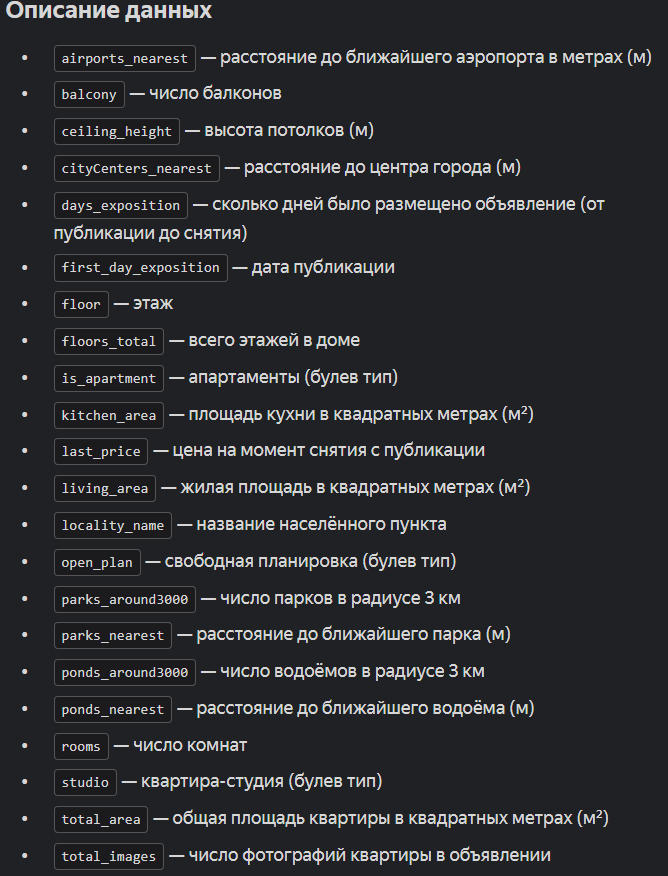

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
   x    – цена одного квадратного метра;
   x    – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
   x    – месяц публикации объявления;
   x    – год публикации объявления;
   x    – тип этажа квартиры (значения — «первый», «последний», «другой»);
   x    – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
   x - построена гистограмма;
   x - рассчитаны среднее и медиана;
   x - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
    x   - общая площадь;
    x   - жилая площадь;
    x   - площадь кухни;
    x   - количество комнат;
    x   - тип этажа, на котором расположена квартира (первый, последний, другой);
    x   - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.

### Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd
import warnings 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    data = pd.read_csv(r'proj_2\real_estate2.ipynb', sep='\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep = '\t')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [4]:
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


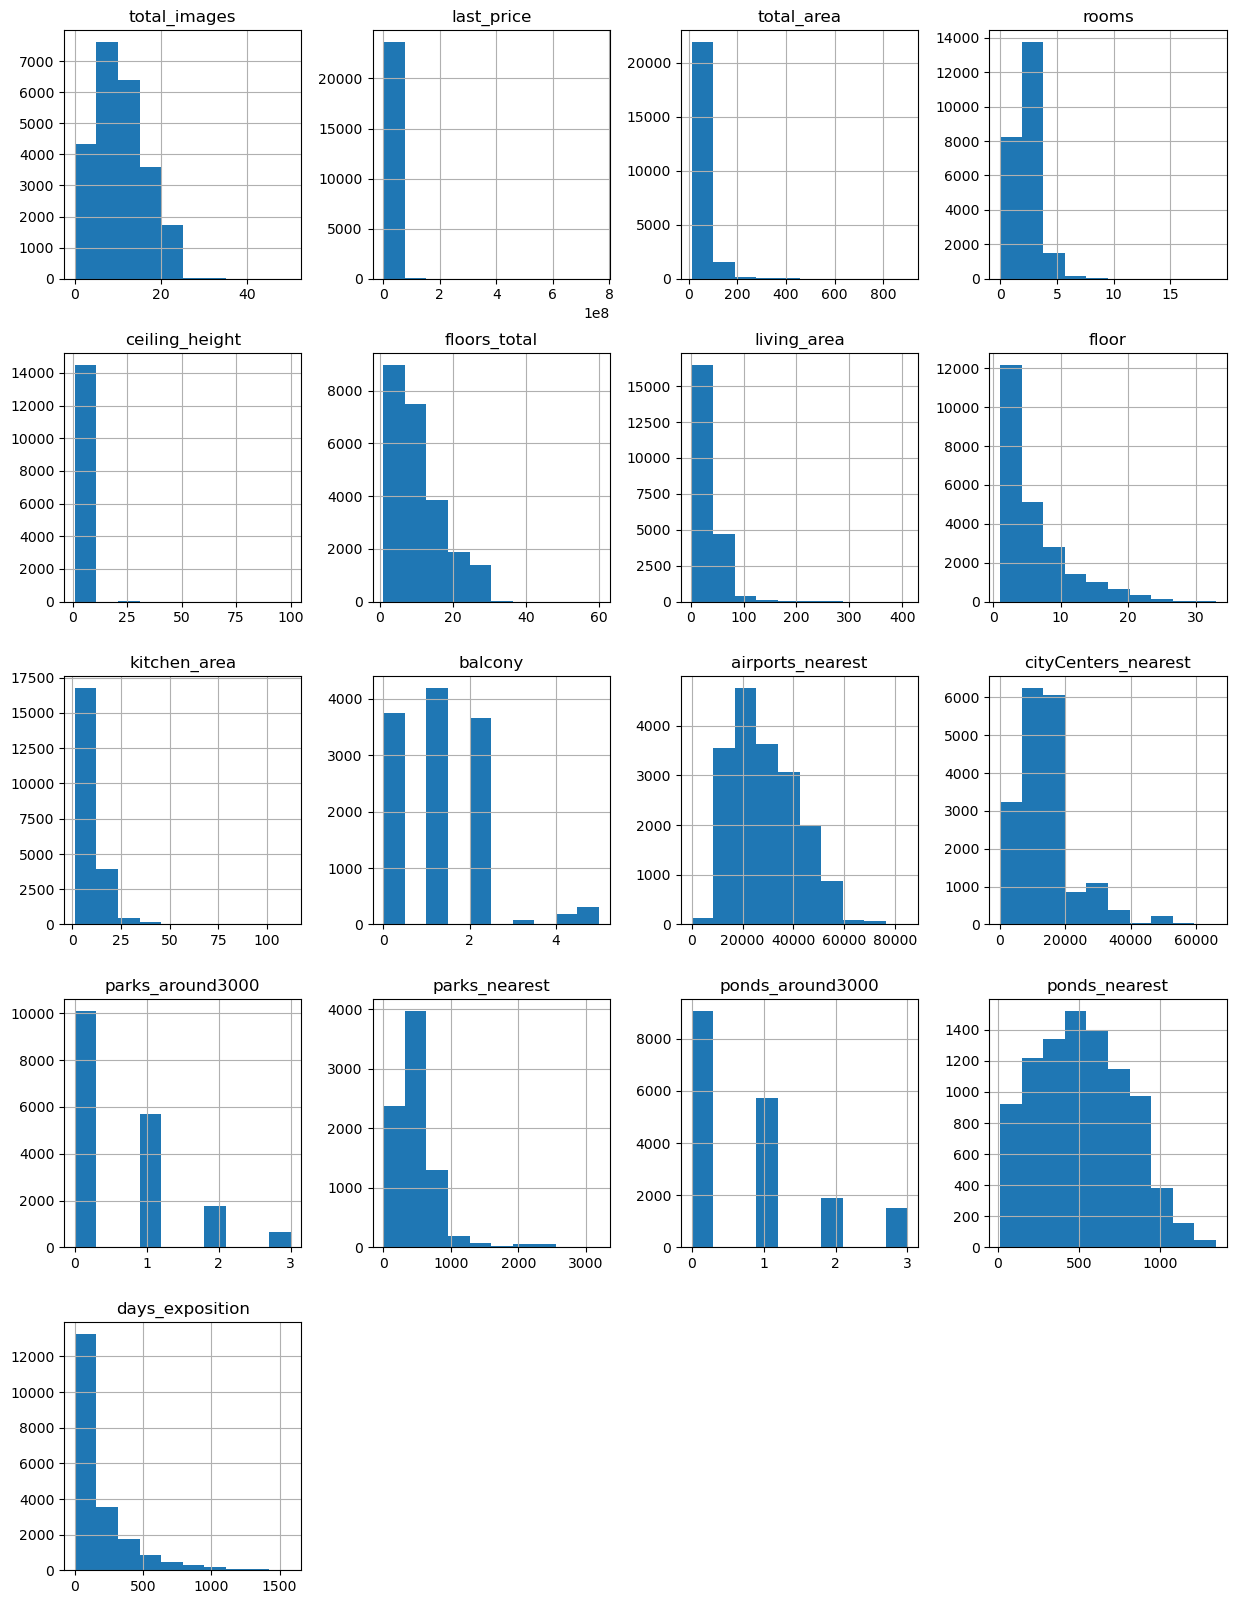

In [5]:
data.hist(figsize=(15, 20))
plt.show();

### 📊 Вывод по гистограммам распределения признаков:

- Большинство признаков имеют **асимметричное распределение**, с явным скошиванием вправо. Это означает, что основная масса значений сосредоточена в нижней части диапазона, но встречаются и высокие значения (возможные выбросы).
- У признаков, таких как `price`, `total_area`, `living_area`, `days_exposition`, наблюдаются **выбросы**, которые могут искажать средние значения. Эти значения стоит проанализировать отдельно.
- Некоторые признаки, такие как `rooms`, `floor`, демонстрируют **многомодальное распределение** с выраженными пиками — это может говорить о популярных типовых решениях в недвижимости (например, 1-, 2-, 3-комнатные квартиры).
- У отдельных признаков возможно наличие **пропущенных или некорректных данных**, что может проявляться в виде резкого обрыва распределения или нулевых частот.
- Общий вид гистограмм указывает на необходимость дальнейшей **очистки данных** (удаление выбросов, заполнение пропусков, нормализация).

> 💡 Рекомендуется дополнительно изучить распределения после обработки выбросов и привести некоторые признаки к нормальному виду при необходимости.


### Выполните предобработку данных

#### Посмотрим пропущенные значения в столбцах

In [6]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

#### В данных много пропущенных значений. Определим значения, находящиеся в стобцах множественными с пропусками.

In [7]:
data['locality_name'].value_counts()

locality_name
Санкт-Петербург                    15721
посёлок Мурино                       522
посёлок Шушары                       440
Всеволожск                           398
Пушкин                               369
                                   ...  
поселок Каложицы                       1
посёлок Платформа 69-й километр        1
поселок Почап                          1
поселок Гончарово                      1
посёлок Дзержинского                   1
Name: count, Length: 364, dtype: int64

#### Пропуски в locality_name ничем заменить нельзя - придется удалить

In [8]:
data = data.dropna(subset=['locality_name'])
data['locality_name'].isna().sum()

0

In [9]:
data['living_area'].value_counts()

living_area
18.00     882
17.00     674
30.00     598
16.00     485
20.00     479
         ... 
94.54       1
17.78       1
77.80       1
129.00      1
42.55       1
Name: count, Length: 1782, dtype: int64

In [10]:
data['ceiling_height'].value_counts()

ceiling_height
2.50    3515
2.60    1645
2.70    1572
3.00    1109
2.80     993
        ... 
5.00       1
2.20       1
2.34       1
3.93       1
3.59       1
Name: count, Length: 183, dtype: int64

In [11]:
data['floors_total'].value_counts()

floors_total
5.0     5775
9.0     3758
16.0    1375
12.0    1361
4.0     1193
10.0    1174
25.0    1075
6.0      910
17.0     833
3.0      667
7.0      589
14.0     553
18.0     505
24.0     462
8.0      388
2.0      381
15.0     365
23.0     349
19.0     339
22.0     286
20.0     271
13.0     229
11.0     202
27.0     164
21.0     158
26.0     124
1.0       25
35.0      24
28.0      21
36.0       3
34.0       1
60.0       1
29.0       1
33.0       1
52.0       1
37.0       1
Name: count, dtype: int64

In [12]:
data['balcony'].value_counts()

balcony
1.0    4187
0.0    3725
2.0    3658
5.0     304
4.0     182
3.0      81
Name: count, dtype: int64

#### Пропуски в 'balcony' заполним нулями, предположмим, что балконов в этих объектах нет

In [13]:
data['balcony'] = data['balcony'].fillna('0')
data['balcony'] = data['balcony'].astype(bool)

#### Столбец с количественными переменными 'ceiling_height' можем заполнить медианными значениями по 'locality_name'

In [14]:
for i in data['locality_name'].unique():
    data.loc[(data['ceiling_height'].isna())&(data['locality_name'] == i), 'ceiling_height'] = data.loc[(data['locality_name'] == i), 'ceiling_height'].median()
data['ceiling_height'].isna().sum()
warnings.filterwarnings('ignore') # отключаем предупреждения


d:\Programms\Anaconda3\envs\env_2\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Programms\Anaconda3\envs\env_2\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Programms\Anaconda3\envs\env_2\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Programms\Anaconda3\envs\env_2\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Programms\Anaconda3\envs\env_2\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Programms\Anaconda3\envs\env_2\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty s

#### Оставшиеся строки с пропущенными знаечниями в столбце 'ceiling_height' удалим

In [15]:
data = data.dropna(subset=['ceiling_height'])
data['ceiling_height'].isna().sum()

0

#### Пропущенные значения стобца 'floors_total' можем удалить - они не повлияют на будущий анализ.

In [16]:
data = data.dropna(subset=['floors_total'])
data['floors_total'].isna().sum()

0

In [17]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area              1841
floor                       0
is_apartment            20697
studio                      0
open_plan                   0
kitchen_area             2194
balcony                     0
locality_name               0
airports_nearest         5409
cityCenters_nearest      5386
parks_around3000         5385
parks_nearest           15415
ponds_around3000         5385
ponds_nearest           14411
days_exposition          3145
dtype: int64

#### Пропуски в стобце 'living_area' заполним медианными значениями по столбцу 'rooms'

In [18]:
for i in data['rooms'].unique():
    data.loc[(data['living_area'].isna())&(data['rooms'] == i), 'living_area'] = \
    data.loc[data['rooms'] == i, 'living_area'].median()
data['living_area'].isna().sum()

0

#### Пропуски в стобце 'is_apartment' заполним нулями, как катеогриальыне данные, означающие отсутствие апартаментов

In [19]:
data['is_apartment'] = data['is_apartment'].fillna(0)
data['is_apartment'].isna().sum()

0

#### Посмотрим, с чем могут быть связаны пропуски в столбце 'kitchen_area'

In [20]:
numeric_data = data.select_dtypes(include=['number'])  # Оставляем только числовые столбцы
correlations = numeric_data.corr()['kitchen_area'].sort_values(ascending=False)
print(correlations)

kitchen_area           1.000000
total_area             0.609155
last_price             0.520094
living_area            0.424392
rooms                  0.270497
floors_total           0.163495
ponds_around3000       0.151151
floor                  0.135613
total_images           0.106774
days_exposition        0.100875
parks_around3000       0.088459
ceiling_height         0.071774
parks_nearest          0.029578
airports_nearest       0.007901
ponds_nearest         -0.104751
cityCenters_nearest   -0.191025
Name: kitchen_area, dtype: float64


#### Учитывая наибольшую корреляцию 'kitchen_area' с 'total_area' заполним пропуски средним отношением площади кухни к площади всей квартиры

In [21]:
mean_ratio = (data[data['kitchen_area'].isna()!=True]['kitchen_area']/data[data['kitchen_area'].isna()!=True]['total_area']).mean() 
mean_ratio

0.18738933439641517

In [22]:
import numpy as np

In [23]:
data.loc[data['kitchen_area'].isna(), 'kitchen_area'] = (data['total_area']*mean_ratio).round(1)
data['kitchen_area'] = np.minimum(data['total_area']-data['living_area'], data['kitchen_area'])

#### Выполним проверку, чтобы жилая площадь не была больше всей площади квартиры

In [24]:
data.loc[(data['kitchen_area']+data['living_area'])>data['total_area']]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


#### Посмотрим оставшиеся пропуски

In [25]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5409
cityCenters_nearest      5386
parks_around3000         5385
parks_nearest           15415
ponds_around3000         5385
ponds_nearest           14411
days_exposition          3145
dtype: int64

#### Пропуски в столбцах 'parks_around3000' и 'ponds_around3000' заполним нулями - значит в радиусе трех километров нет парков и прудов

In [26]:
data['parks_around3000'] = data['parks_around3000'].fillna(0)
data['parks_around3000'].isna().sum()

0

In [27]:
data['ponds_around3000'] = data['ponds_around3000'].fillna(0)
data['ponds_around3000'].isna().sum()

0

#### Пропуски в столбцах: 'airports_nearest', 'cityCenters_nearest', 'parks_nearest', 'ponds_nearest' - заполним максимальным удаленным значением соответсвующего столбца. Удалять строки с эти пропусками нельзя так как они занимают 20% всего датасета.

In [28]:
print(data['airports_nearest'].max()) #максимальное расстояние до аэропорта

84869.0


In [29]:
data.loc[data['airports_nearest'].isna(), 'airports_nearest'] = data['airports_nearest'].max()
data['airports_nearest'].isna().sum()

0

In [30]:
print(data['cityCenters_nearest'].max()) #максимальное расстояние до торгового центра

65968.0


In [31]:
data.loc[data['cityCenters_nearest'].isna(), 'cityCenters_nearest'] = data['cityCenters_nearest'].max()
data['cityCenters_nearest'].isna().sum()

0

In [32]:
print(data['parks_nearest'].max()) #максимальное расстояние до парка

3190.0


In [33]:
data.loc[data['parks_nearest'].isna(), 'parks_nearest'] = data['parks_nearest'].max()
data['parks_nearest'].isna().sum()

0

In [34]:
print(data['ponds_nearest'].max()) #максимальное расстояние до парка

1344.0


In [35]:
data.loc[data['ponds_nearest'].isna(), 'ponds_nearest'] = data['ponds_nearest'].max()
data['ponds_nearest'].isna().sum()

0

#### Посмотрим оставшиеся пропуски

In [36]:
data.isna().sum()

total_images               0
last_price                 0
total_area                 0
first_day_exposition       0
rooms                      0
ceiling_height             0
floors_total               0
living_area                0
floor                      0
is_apartment               0
studio                     0
open_plan                  0
kitchen_area               0
balcony                    0
locality_name              0
airports_nearest           0
cityCenters_nearest        0
parks_around3000           0
parks_nearest              0
ponds_around3000           0
ponds_nearest              0
days_exposition         3145
dtype: int64

#### Подумаем, чем заменить пропуски в столбце days_exposition.

##### Посмотрим уникальные значения

In [37]:
data['days_exposition'].sort_values(ascending=False)

18843    1580.0
1109     1572.0
9553     1553.0
1885     1513.0
20969    1512.0
          ...  
23683       NaN
23684       NaN
23685       NaN
23694       NaN
23698       NaN
Name: days_exposition, Length: 23445, dtype: float64

##### Похоже, что выбросов в этом столбце нет. Заменим пропуски медианным значениям по столбцу 'locality_name'

In [38]:
data['days_exposition'] = data.groupby('locality_name')['days_exposition'].transform(lambda x: x.fillna(x.median()))
data['days_exposition'].isna().sum()
warnings.filterwarnings('ignore') # отключаем предупреждения

##### Оставшиеся пропуски, которым не нашлось соответсвие в locality_name, удалим

In [39]:
data = data.dropna(subset=['days_exposition'])
data['days_exposition'].isna().sum()

0

#### Установим корректный тип данных в стобцах

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23381 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23381 non-null  int64  
 1   last_price            23381 non-null  float64
 2   total_area            23381 non-null  float64
 3   first_day_exposition  23381 non-null  object 
 4   rooms                 23381 non-null  int64  
 5   ceiling_height        23381 non-null  float64
 6   floors_total          23381 non-null  float64
 7   living_area           23381 non-null  float64
 8   floor                 23381 non-null  int64  
 9   is_apartment          23381 non-null  object 
 10  studio                23381 non-null  bool   
 11  open_plan             23381 non-null  bool   
 12  kitchen_area          23381 non-null  float64
 13  balcony               23381 non-null  bool   
 14  locality_name         23381 non-null  object 
 15  airports_nearest      23

##### Поменяем тип данных 'days_exposition' на int, так как количество дней - целое число

In [41]:
data['days_exposition'] = data['days_exposition'].astype(int)

##### Поменяем тип данных 'floors_total' на int, так как количество этажей - целое число

In [42]:
data['floors_total'] = data['floors_total'].astype(int)

##### Поменяем тип данных 'is_apartment' на bool, так как это категориальное значение

In [43]:
data['is_apartment'] = data['is_apartment'].astype(bool)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23381 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23381 non-null  int64  
 1   last_price            23381 non-null  float64
 2   total_area            23381 non-null  float64
 3   first_day_exposition  23381 non-null  object 
 4   rooms                 23381 non-null  int64  
 5   ceiling_height        23381 non-null  float64
 6   floors_total          23381 non-null  int32  
 7   living_area           23381 non-null  float64
 8   floor                 23381 non-null  int64  
 9   is_apartment          23381 non-null  bool   
 10  studio                23381 non-null  bool   
 11  open_plan             23381 non-null  bool   
 12  kitchen_area          23381 non-null  float64
 13  balcony               23381 non-null  bool   
 14  locality_name         23381 non-null  object 
 15  airports_nearest      23

#### Устраним неявные дупликаты в названиях населенных пунктов

##### Посмотрим уникальные значения стобца 'locality_name'

In [45]:
sorted(data['locality_name'].unique())

['Бокситогорск',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Высоцк',
 'Гатчина',
 'Зеленогорск',
 'Ивангород',
 'Каменногорск',
 'Кингисепп',
 'Кириши',
 'Кировск',
 'Колпино',
 'Коммунар',
 'Красное Село',
 'Кронштадт',
 'Кудрово',
 'Лодейное Поле',
 'Ломоносов',
 'Луга',
 'Любань',
 'Никольское',
 'Новая Ладога',
 'Отрадное',
 'Павловск',
 'Петергоф',
 'Пикалёво',
 'Подпорожье',
 'Приморск',
 'Приозерск',
 'Пушкин',
 'Санкт-Петербург',
 'Светогорск',
 'Сертолово',
 'Сестрорецк',
 'Сланцы',
 'Сосновый Бор',
 'Сясьстрой',
 'Тихвин',
 'Тосно',
 'Шлиссельбург',
 'городской поселок Большая Ижора',
 'городской поселок Янино-1',
 'городской посёлок Будогощь',
 'городской посёлок Виллози',
 'городской посёлок Мга',
 'городской посёлок Назия',
 'городской посёлок Новоселье',
 'городской посёлок Павлово',
 'городской посёлок Рощино',
 'городской посёлок Свирьстрой',
 'городской посёлок Фёдоровское',
 'городской посёлок Янино-1',
 'деревня Агалатово',
 'деревня Батово',
 'деревня Бегун

##### Найдены дупликаты 'городской посёлок Янино-1'-'городской поселок Янино-1'. Заменим в слове букву е на букву ё.

In [46]:
data['locality_name'] = data['locality_name'].replace({'городской поселок Янино-1':'городской посёлок Янино-1'})
sorted(data['locality_name'].unique())

['Бокситогорск',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Высоцк',
 'Гатчина',
 'Зеленогорск',
 'Ивангород',
 'Каменногорск',
 'Кингисепп',
 'Кириши',
 'Кировск',
 'Колпино',
 'Коммунар',
 'Красное Село',
 'Кронштадт',
 'Кудрово',
 'Лодейное Поле',
 'Ломоносов',
 'Луга',
 'Любань',
 'Никольское',
 'Новая Ладога',
 'Отрадное',
 'Павловск',
 'Петергоф',
 'Пикалёво',
 'Подпорожье',
 'Приморск',
 'Приозерск',
 'Пушкин',
 'Санкт-Петербург',
 'Светогорск',
 'Сертолово',
 'Сестрорецк',
 'Сланцы',
 'Сосновый Бор',
 'Сясьстрой',
 'Тихвин',
 'Тосно',
 'Шлиссельбург',
 'городской поселок Большая Ижора',
 'городской посёлок Будогощь',
 'городской посёлок Виллози',
 'городской посёлок Мга',
 'городской посёлок Назия',
 'городской посёлок Новоселье',
 'городской посёлок Павлово',
 'городской посёлок Рощино',
 'городской посёлок Свирьстрой',
 'городской посёлок Фёдоровское',
 'городской посёлок Янино-1',
 'деревня Агалатово',
 'деревня Батово',
 'деревня Бегуницы',
 'деревня Белогорка',
 '

#### Произведем поиск аномальных значений

##### Начнем со значений столбца 'floors'. Главное условие: чтобы значения были меньше 'floors_total'.

In [47]:
data.loc[data['floor']>data['floors_total']]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


##### Таких не оказалось - хорошо. Посмотрим теперь столбец 'living_area': главное условие состоит в том, чтобы его сначения были меньше или равны 'total_area'.

In [48]:
data.loc[data['living_area']>data['total_area']]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1595,7,3200000.0,62.4,2019-04-23T00:00:00,4,2.50,5,63.800,2,False,...,-1.400,True,Кингисепп,84869.0,65968.0,0.0,3190.0,0.0,1344.0,53
3374,18,3650000.0,41.5,2018-02-14T00:00:00,3,2.50,5,45.000,3,False,...,-3.500,True,Санкт-Петербург,12842.0,11005.0,0.0,3190.0,1.0,745.0,24
8976,5,4350000.0,41.2,2017-03-17T00:00:00,3,2.50,5,45.000,3,False,...,-3.800,True,Санкт-Петербург,14918.0,9601.0,0.0,3190.0,1.0,694.0,560
9795,10,4000000.0,42.0,2017-11-20T00:00:00,3,2.50,5,45.000,3,False,...,-3.000,True,Санкт-Петербург,11284.0,12562.0,1.0,358.0,1.0,117.0,276
9964,5,3500000.0,49.5,2018-10-02T00:00:00,4,2.70,5,63.800,1,False,...,-14.300,True,Санкт-Петербург,11609.0,10539.0,0.0,3190.0,1.0,96.0,63
11814,1,3490000.0,42.0,2018-02-12T00:00:00,3,2.70,5,45.000,1,False,...,-3.000,True,Санкт-Петербург,11605.0,12577.0,0.0,3190.0,0.0,1344.0,36
11977,5,2850000.0,62.0,2018-07-08T00:00:00,4,2.65,5,63.800,1,False,...,-1.800,True,Кингисепп,84869.0,65968.0,0.0,3190.0,0.0,1344.0,45
12040,5,1900000.0,15.0,2018-06-27T00:00:00,1,2.50,5,17.600,1,False,...,-2.600,True,Сосновый Бор,84869.0,65968.0,0.0,3190.0,0.0,1344.0,45
12129,0,1150000.0,30.0,2018-08-05T00:00:00,2,2.50,5,30.500,2,False,...,-0.500,True,городской посёлок Мга,84869.0,65968.0,0.0,3190.0,0.0,1344.0,45
12186,1,4900000.0,71.4,2017-09-21T00:00:00,5,2.60,9,91.785,7,False,...,-20.385,True,Санкт-Петербург,13592.0,14670.0,1.0,430.0,0.0,1344.0,133


##### Таких оказалось 29 строк - удалим их.

In [49]:
data = data.loc[data['kitchen_area']>0]

##### Выполним проверку

In [50]:
data.loc[data['living_area']>data['total_area']]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


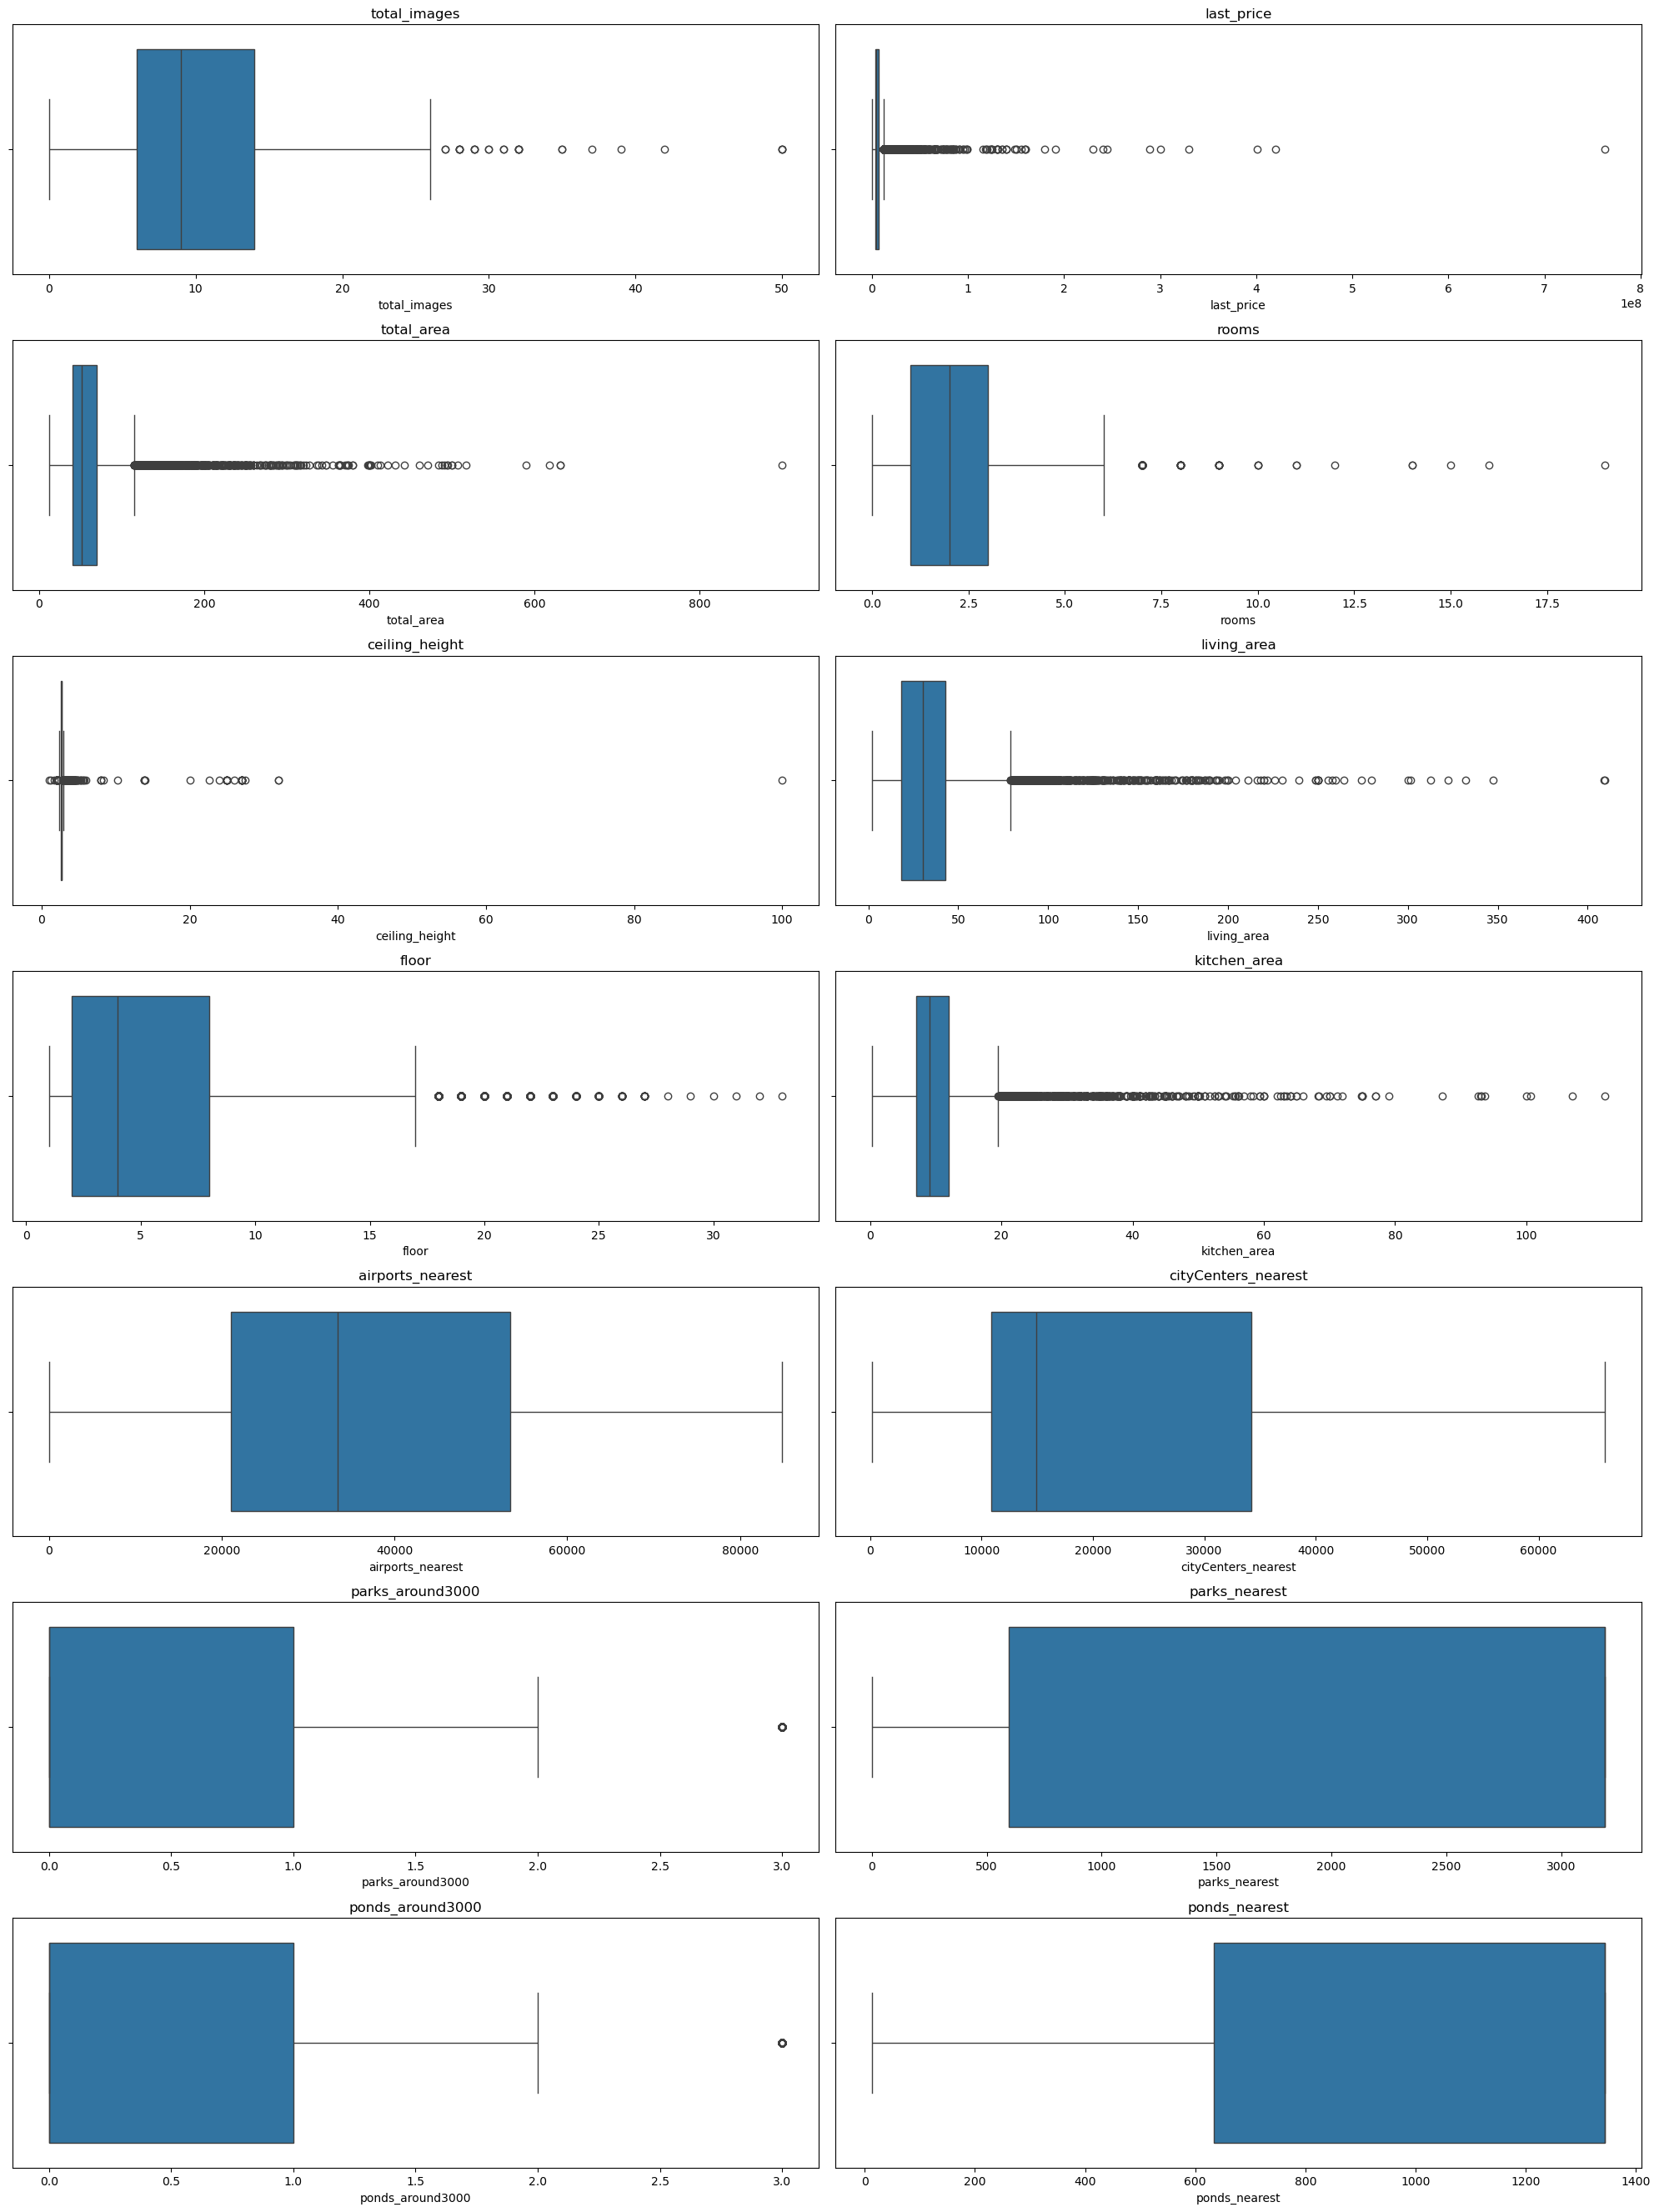

In [51]:
# Выбираем только числовые столбцы
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

# Настройки визуализации
plt.figure(figsize=(20, 30))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 2 + 1, 2, i)
    sns.boxplot(x=data[column])
    plt.title(column)
    plt.tight_layout()

plt.show()


##### Оценивая построенные графики, можно сделать выводы, на фоне самых популярныз квартир с общей площадью 80 квадратных метров выделяются квартиры с более чем 200 кв м. Ввыбросами это называть рано, так как это могут быть действительно дорогие и роскошные квартиры. Но высота потолков выше 5 метров действительно вызывают подозрение.

In [52]:
data.loc[data['ceiling_height']>5].sort_values(by='ceiling_height',ascending=False)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
22869,0,15000000.0,25.0,2018-07-25T00:00:00,1,100.00,5,14.000,5,True,...,11.0,True,Санкт-Петербург,34963.0,8283.0,1.0,223.0,3.0,30.0,19
22336,19,9999000.0,92.4,2019-04-05T00:00:00,2,32.00,6,55.500,5,False,...,16.5,True,Санкт-Петербург,18838.0,3506.0,0.0,3190.0,3.0,511.0,95
3148,14,2900000.0,75.0,2018-11-12T00:00:00,3,32.00,3,53.000,2,False,...,8.0,True,Волхов,84869.0,65968.0,0.0,3190.0,0.0,1344.0,104
21377,19,4900000.0,42.0,2017-04-18T00:00:00,1,27.50,24,37.700,19,False,...,4.3,True,Санкт-Петербург,42742.0,9760.0,0.0,3190.0,0.0,1344.0,61
10773,8,3800000.0,58.0,2017-10-13T00:00:00,2,27.00,10,30.100,3,False,...,8.1,True,посёлок Мурино,84869.0,65968.0,0.0,3190.0,0.0,1344.0,71
5246,0,2500000.0,54.0,2017-10-13T00:00:00,2,27.00,5,30.000,3,False,...,9.0,True,деревня Мины,84869.0,65968.0,0.0,3190.0,0.0,1344.0,540
21824,20,2450000.0,44.0,2019-02-12T00:00:00,2,27.00,2,38.000,2,False,...,6.0,True,городской поселок Большая Ижора,84869.0,65968.0,0.0,3190.0,0.0,1344.0,58
20478,11,8000000.0,45.0,2017-07-18T00:00:00,1,27.00,4,22.000,2,False,...,10.0,True,Санкт-Петербург,18975.0,3246.0,0.0,3190.0,3.0,449.0,429
17857,1,3900000.0,56.0,2017-12-22T00:00:00,3,27.00,5,33.000,4,False,...,10.5,True,Санкт-Петербург,41030.0,15543.0,0.0,3190.0,0.0,1344.0,73
5807,17,8150000.0,80.0,2019-01-09T00:00:00,2,27.00,36,41.000,13,False,...,12.0,True,Санкт-Петербург,18732.0,20444.0,0.0,3190.0,3.0,80.0,38


##### Можно уверенно назвать их выбросами, так как в остальном эти объекты имеют средние показатели.

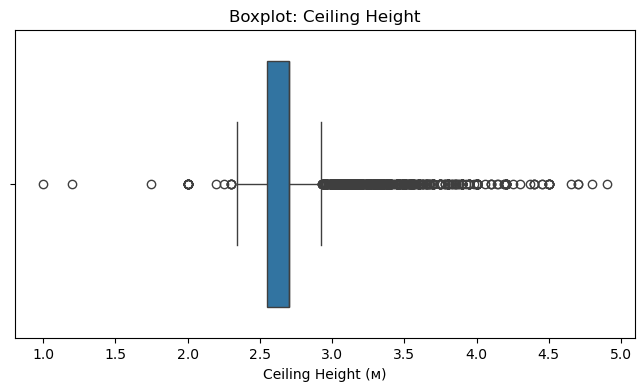

In [53]:
data = data.loc[data['ceiling_height']<5]
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['ceiling_height'])
plt.title('Boxplot: Ceiling Height')
plt.xlabel('Ceiling Height (м)')
plt.show()

In [54]:
data.sort_values(by='ceiling_height', ascending=False)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
21923,10,115490000.0,235.0,2017-04-09T00:00:00,5,4.90,5,140.0,5,False,...,50.00,True,Санкт-Петербург,22777.0,1328.0,3.0,652.0,3.0,253.0,351
2802,7,14950000.0,50.0,2016-03-06T00:00:00,2,4.80,3,30.0,2,False,...,10.00,False,Санкт-Петербург,24433.0,1725.0,1.0,589.0,3.0,161.0,160
1300,14,120000000.0,280.0,2018-07-12T00:00:00,5,4.70,4,162.0,3,False,...,30.00,True,Санкт-Петербург,24680.0,4247.0,1.0,464.0,3.0,339.0,225
19142,10,8650000.0,87.7,2017-07-18T00:00:00,2,4.70,26,57.4,26,False,...,25.00,True,Санкт-Петербург,40648.0,9888.0,1.0,1248.0,0.0,1344.0,15
12401,20,91500000.0,495.0,2017-06-19T00:00:00,7,4.65,7,347.5,7,False,...,25.00,False,Санкт-Петербург,84869.0,5735.0,2.0,110.0,0.0,1344.0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22960,17,2300000.0,53.6,2018-10-18T00:00:00,2,2.00,2,19.0,1,False,...,10.00,True,Всеволожск,84869.0,65968.0,0.0,3190.0,0.0,1344.0,123
2572,4,2400000.0,62.0,2018-12-27T00:00:00,3,2.00,5,40.0,4,False,...,6.00,True,Луга,84869.0,65968.0,0.0,3190.0,0.0,1344.0,63
16934,5,4100000.0,40.0,2017-10-17T00:00:00,1,1.75,37,17.4,5,False,...,8.34,True,Санкт-Петербург,18732.0,20444.0,0.0,3190.0,3.0,80.0,71
5712,5,1500000.0,42.8,2017-08-14T00:00:00,2,1.20,2,27.5,1,False,...,5.20,True,городской посёлок Мга,84869.0,65968.0,0.0,3190.0,0.0,1344.0,248


##### Посмотрим теперь на столбец 'total_area', какие аномалии могут быть там.

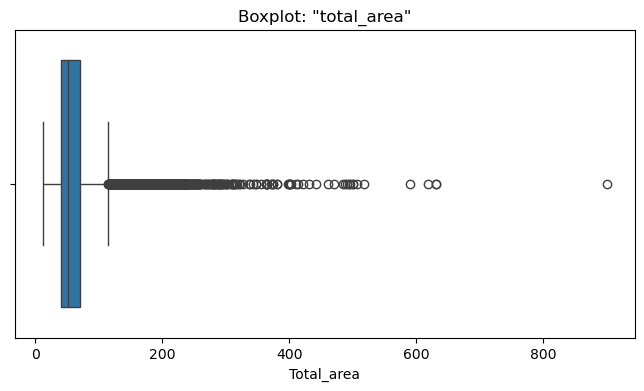

In [55]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['total_area'])
plt.title('Boxplot: "total_area"')
plt.xlabel('Total_area')
plt.show()

##### Исследуем квартиры с площадью более 300 квадратных метров

In [56]:
data.sort_values(by='total_area', ascending=False)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
19540,8,420000000.0,900.0,2017-12-06T00:00:00,12,2.80,25,409.7,25,False,...,112.0,True,Санкт-Петербург,30706.0,7877.0,0.0,3190.0,2.0,318.0,106
12859,20,140000000.0,631.2,2019-04-09T00:00:00,7,3.90,4,322.3,4,False,...,19.5,True,Санкт-Петербург,25707.0,4972.0,0.0,3190.0,2.0,210.0,95
3117,19,140000000.0,631.0,2019-03-30T00:00:00,7,2.70,5,145.0,5,False,...,60.0,True,Санкт-Петербург,25707.0,4972.0,0.0,3190.0,2.0,210.0,95
15651,20,300000000.0,618.0,2017-12-18T00:00:00,7,3.40,7,258.0,5,False,...,70.0,True,Санкт-Петербург,32440.0,5297.0,0.0,3190.0,2.0,198.0,111
5358,20,65000000.0,590.0,2019-02-14T00:00:00,15,3.50,6,409.0,3,False,...,100.0,True,Санкт-Петербург,24447.0,4666.0,1.0,767.0,0.0,1344.0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9412,5,2100000.0,16.0,2017-12-10T00:00:00,0,2.70,6,13.0,1,False,...,3.0,True,Санкт-Петербург,20735.0,2111.0,2.0,228.0,3.0,72.0,3
8886,10,2450000.0,15.5,2018-08-22T00:00:00,0,2.70,5,10.0,2,False,...,2.9,True,Санкт-Петербург,24326.0,4589.0,0.0,3190.0,1.0,446.0,27
19642,5,1190000.0,14.0,2018-07-29T00:00:00,1,2.70,5,11.0,1,False,...,2.0,True,Санкт-Петербург,9898.0,11122.0,0.0,3190.0,0.0,1344.0,4
19807,0,3800000.0,13.0,2018-07-04T00:00:00,1,2.70,5,10.0,3,False,...,2.4,True,Санкт-Петербург,21302.0,1242.0,1.0,592.0,3.0,27.0,9


##### По общей площади вывод делать трудно, так как квартиры действительно бывают роскошные и поэтому недешевые.  
##### Посмотрим на стобец с ценами и логически попробуем соотнести с вероятностью их существования в России.

In [57]:
data.sort_values(by='last_price', ascending=False)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
12971,19,763000000.0,400.0,2017-09-30T00:00:00,7,2.700,10,250.0,10,False,...,75.0,True,Санкт-Петербург,25108.0,3956.0,1.0,530.0,3.0,756.0,33
19540,8,420000000.0,900.0,2017-12-06T00:00:00,12,2.800,25,409.7,25,False,...,112.0,True,Санкт-Петербург,30706.0,7877.0,0.0,3190.0,2.0,318.0,106
14706,15,401300000.0,401.0,2016-02-20T00:00:00,5,2.700,9,204.0,9,False,...,24.0,True,Санкт-Петербург,21912.0,2389.0,1.0,545.0,1.0,478.0,393
1436,19,330000000.0,190.0,2018-04-04T00:00:00,3,3.500,7,95.0,5,False,...,40.0,True,Санкт-Петербург,23011.0,1197.0,3.0,519.0,3.0,285.0,233
15651,20,300000000.0,618.0,2017-12-18T00:00:00,7,3.400,7,258.0,5,False,...,70.0,True,Санкт-Петербург,32440.0,5297.0,0.0,3190.0,2.0,198.0,111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21912,0,470000.0,37.0,2018-02-18T00:00:00,1,2.600,3,17.6,3,False,...,6.9,True,поселок Совхозный,84869.0,65968.0,0.0,3190.0,0.0,1344.0,45
5698,7,450000.0,42.0,2017-07-31T00:00:00,2,2.615,1,23.0,1,False,...,5.8,True,городской посёлок Будогощь,84869.0,65968.0,0.0,3190.0,0.0,1344.0,233
16219,14,450000.0,38.5,2018-07-11T00:00:00,2,2.650,2,30.5,1,False,...,7.2,True,деревня Вахнова Кара,84869.0,65968.0,0.0,3190.0,0.0,1344.0,45
17456,7,430000.0,30.4,2019-04-22T00:00:00,1,2.500,2,16.0,1,False,...,6.0,True,Сланцы,84869.0,65968.0,0.0,3190.0,0.0,1344.0,86


##### Уберем из рассмотрения несколько самых дорогих квартир свыше пятидесяти миллионов рублей, чтобы они не помешали нам сделать качественный анализ. И посмотрим как сейчас стали выглядеть графики размаха.

In [58]:
data = data.loc[data['last_price']<50000000]

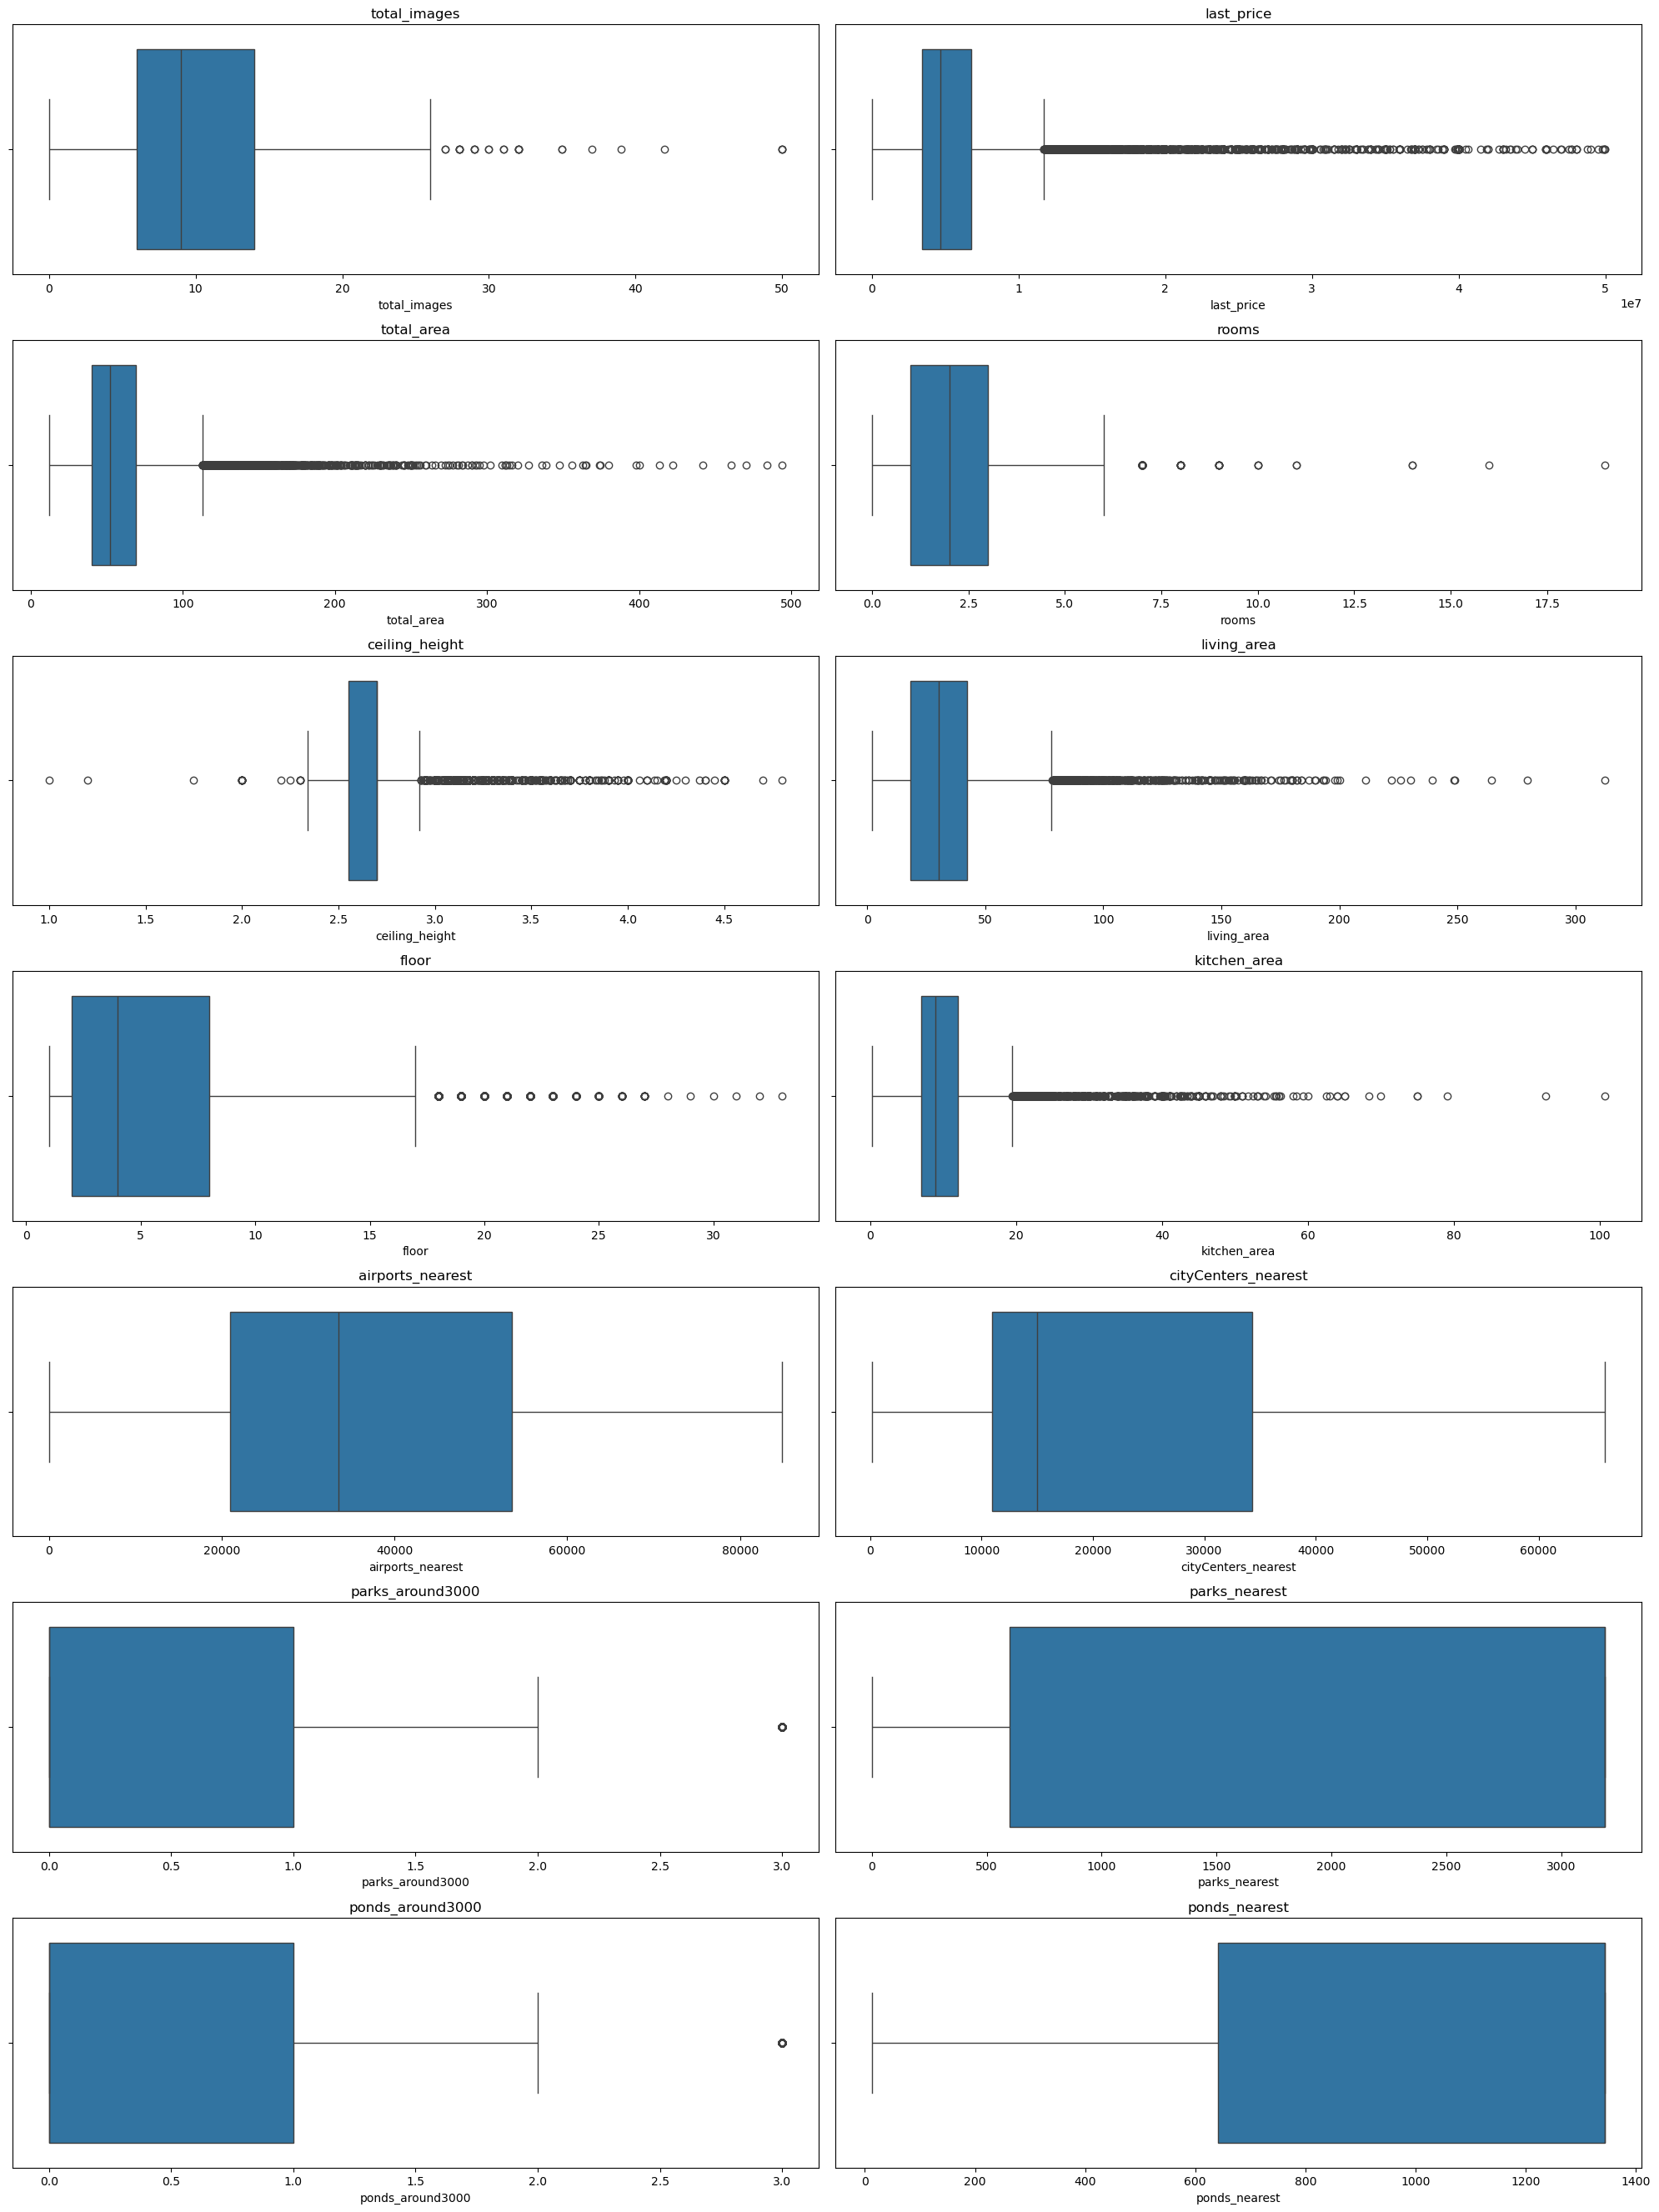

In [59]:
# Выбираем только числовые столбцы
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

# Настройки визуализации
plt.figure(figsize=(20, 30))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 2 + 1, 2, i)
    sns.boxplot(x=data[column])
    plt.title(column)
    plt.tight_layout()

plt.show()

In [60]:
data.duplicated().sum() #явных дубликатов не обнаружено

0

### 📌 Основные наблюдения:

1. **`last_price` (цена недвижимости):**
   - До очистки присутствовали сильные выбросы (до 300+ млн руб).
   - После удаления квартир дороже 50 млн руб. распределение стало ближе к нормальному.

2. **`total_area`, `living_area`, `kitchen_area`:**
   - Наблюдаются отдельные экстремальные значения (до 900 м² и более), но они объясняются элитной недвижимостью.
   - Основная масса данных:
     - `total_area`: до 120 м²
     - `living_area`: до 80 м²
     - `kitchen_area`: до 25 м²

3. **`ceiling_height` (высота потолков):**
   - Большинство квартир имеют высоту потолков 2.5–3.0 м.
   - Значения выше 5 м расценены как аномальные и удалены.

4. **`days_exposition` (срок продажи):**
   - Большая часть продаж укладывается в диапазон 45–200 дней.
   - Выбросы (объекты, не продававшиеся годами) оставлены как реальные случаи.

5. **Прочие признаки (`floor`, `floors_total`, `rooms`, расстояния до объектов и т.д.):**
   - Явных аномалий не выявлено, логические ошибки устранены на этапе очистки.

### 🧪 Качество исходных данных:

- Данные содержали **большое количество пропусков** в критически важных столбцах:
  - `living_area`, `kitchen_area`, `ceiling_height`, `floors_total`, `days_exposition` и пр.
- Некоторые значения были **логически некорректны**:
  - примеры: `floor > floors_total`, `living_area > total_area`.
- Обнаружены **дубликаты в наименованиях населённых пунктов**, устранены вручную.
- Наблюдались значительные **аномалии**:
  - завышенные цены (до 300 млн руб),
  - экстремальные площади (до 900 м²),
  - потолки выше 10 метров и т.п.

### Добавьте в таблицу новые столбцы

##### Добавим в таблицу столбец с ценами квартир за квадратный метр.

In [61]:
data['cost_per_sqm'] = data['last_price']/data['total_area']
data.sort_values(by='cost_per_sqm', ascending=False)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,cost_per_sqm
4859,16,28000000.0,33.00,2019-04-29T00:00:00,1,3.50,5,17.60,2,False,...,True,Санкт-Петербург,23447.0,1376.0,3.0,344.0,3.0,119.0,95,848484.848485
17172,14,28000000.0,33.00,2019-04-30T00:00:00,1,3.50,5,17.60,2,False,...,True,Санкт-Петербург,23403.0,1462.0,3.0,342.0,3.0,27.0,95,848484.848485
8322,20,39900000.0,55.30,2017-10-26T00:00:00,1,3.05,6,35.00,4,False,...,True,Санкт-Петербург,25685.0,2136.0,1.0,72.0,3.0,202.0,95,721518.987342
21238,1,24412900.0,38.12,2018-06-27T00:00:00,1,2.70,10,16.83,4,False,...,True,Всеволожск,84869.0,65968.0,0.0,3190.0,0.0,1344.0,44,640422.350472
6127,13,40000000.0,65.30,2017-07-13T00:00:00,2,4.10,5,45.00,2,False,...,True,Санкт-Петербург,23308.0,2380.0,1.0,473.0,1.0,283.0,497,612557.427259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23484,11,470000.0,44.50,2018-07-02T00:00:00,2,2.50,2,28.00,2,False,...,True,Сланцы,84869.0,65968.0,0.0,3190.0,0.0,1344.0,298,10561.797753
23477,3,1450000.0,138.00,2018-07-06T00:00:00,3,2.55,2,58.00,2,False,...,True,Гатчина,84869.0,65968.0,0.0,3190.0,0.0,1344.0,52,10507.246377
11351,17,550000.0,54.00,2019-02-07T00:00:00,2,3.00,2,40.00,1,False,...,True,Сланцы,84869.0,65968.0,0.0,3190.0,0.0,1344.0,78,10185.185185
4405,9,500000.0,52.00,2018-08-02T00:00:00,2,2.70,2,31.00,1,False,...,True,Сланцы,84869.0,65968.0,0.0,3190.0,0.0,1344.0,110,9615.384615


##### Добавим в таблицу столбец с номером дня недели выставленного объявления.

In [62]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition']) #поменяем тип стобца на data
data['first_day_exposition']

0       2019-03-07
1       2018-12-04
2       2015-08-20
4       2018-06-19
5       2018-09-10
           ...    
23693   2016-08-05
23694   2017-03-21
23695   2018-01-15
23697   2017-03-28
23698   2017-07-21
Name: first_day_exposition, Length: 23175, dtype: datetime64[ns]

In [63]:
data['week_day'] = data['first_day_exposition'].dt.weekday
data['week_day'].value_counts()

week_day
3    4204
1    4108
4    3905
2    3887
0    3537
5    1882
6    1652
Name: count, dtype: int64

##### Добавим столбец с номером месяца выставленного объявления

In [64]:
data['month'] = data['first_day_exposition'].dt.month
data['month'].value_counts()

month
2     2589
3     2519
11    2328
4     2303
10    2087
9     1946
6     1717
8     1716
7     1658
12    1599
1     1468
5     1245
Name: count, dtype: int64

##### Добавим столбец с номером года выставленного объявления

In [65]:
data['year'] = data['first_day_exposition'].dt.year
data['year'].value_counts()

year
2018    8363
2017    8057
2019    2780
2016    2705
2015    1137
2014     133
Name: count, dtype: int64

##### Добавим столбец с типом этажа выставленной квартиры.

In [66]:
def type_floor(row):
    if row['floor'] == 1:
        return 'Первый'
    if row['floor'] == row['floors_total']:
        return 'Последний'
    else:
        return 'Другой'

data['floor_type'] = data.apply(type_floor, axis=1)
data['floor_type'].value_counts()

floor_type
Другой       17100
Последний     3233
Первый        2842
Name: count, dtype: int64

##### Добавим столбец с расстоянием до центра города от выставленной квартиры в километрах.

In [67]:
data['cityCenters_nearest_km'] = data['cityCenters_nearest']/1000
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,cost_per_sqm,week_day,month,year,floor_type,cityCenters_nearest_km
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,482.0,2.0,755.0,95,120370.370370,3,3,2019,Другой,16.028
1,7,3350000.0,40.4,2018-12-04,1,2.63,11,18.6,1,False,...,3190.0,0.0,1344.0,81,82920.792079,1,12,2018,Первый,18.603
2,10,5196000.0,56.0,2015-08-20,2,2.70,5,34.3,4,False,...,90.0,2.0,574.0,558,92785.714286,3,8,2015,Другой,13.933
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,...,112.0,1.0,48.0,121,100000.000000,1,6,2018,Другой,8.098
5,10,2890000.0,30.4,2018-09-10,1,2.60,12,14.4,5,False,...,3190.0,0.0,1344.0,55,95065.789474,0,9,2018,Другой,65.968


Text(0, 0.5, 'Количество объектов')

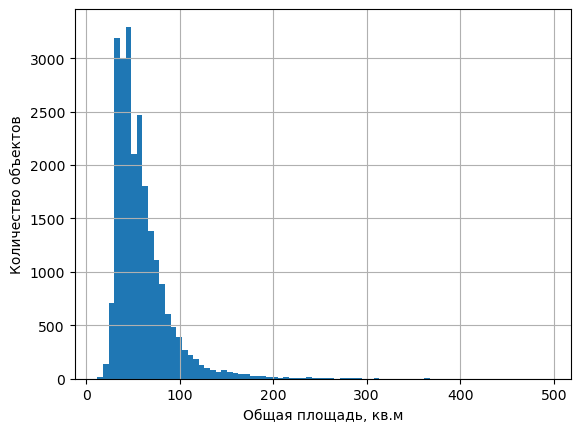

In [68]:
data['total_area'].hist(bins=80)
plt.xlabel('Общая площадь, кв.м')
plt.ylabel('Количество объектов')

##### По гистограмме общей площади можно сказать, что наибольшее число квартир имеют площадь в диапазоне 40~70 кв.м. График кососеммитричен и сосредоточен слева. Также есть редкие значения (больше 200 кв.м). Это элитное жилье премиум-класса.

Text(0, 0.5, 'Количество объектов')

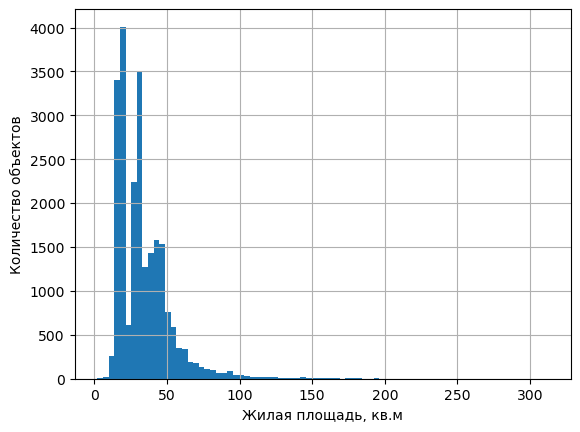

In [69]:
data['living_area'].hist(bins=80)
plt.xlabel('Жилая площадь, кв.м')
plt.ylabel('Количество объектов')

##### По гистограмме жилой площади можно сказать, что жилая площадь повторяте график общей. Большиснвто жилых помещений имеют плозадь от 30 до 50 кв.м. График кососеммитричен и сосредоточен слева. Интересно принять в рассмотрение пропасть в районе 40 кв.м. Это связано с особенностью планировок квартир и нормативными особенностями строительства. Также есть редкие значения (больше 100 кв.м). Это элитное жилье премиум-класса.

Text(0, 0.5, 'Количество объектов')

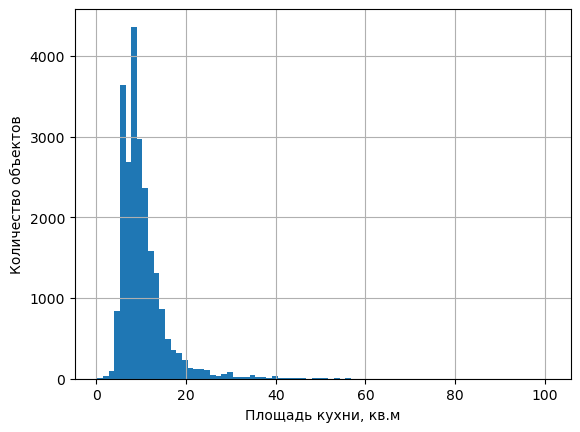

In [70]:
data['kitchen_area'].hist(bins=80)
plt.xlabel('Площадь кухни, кв.м')
plt.ylabel('Количество объектов')

##### По гистограмме площади кухни можно сказать, что жилая площадь повторяте график общей площади. Большинство кухонь имеют площадь от 5 до 15 кв.м. График кососеммитричен и сосредоточен слева. Интересно принять в рассмотрение пропасть в районе 40 кв.м. Это связано с особенностью планировок квартир и нормативными особенностями строительства. Также есть редкие значения (больше 30 кв.м). Это элитное жилье премиум-класса.

Text(0, 0.5, 'Количество объектов')

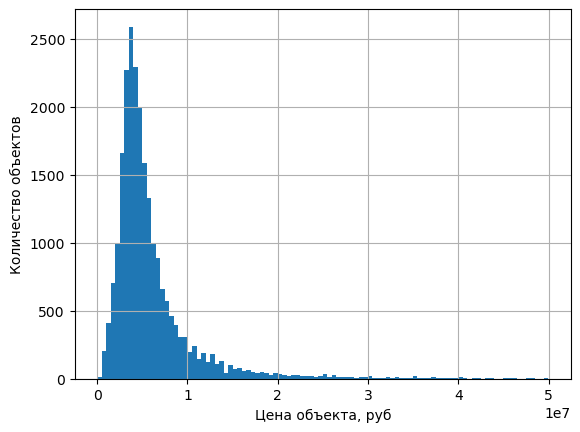

In [71]:
data['last_price'].hist(bins=100)
plt.xlabel('Цена объекта, руб')
plt.ylabel('Количество объектов')

##### По гистограмме цены жилья можно сказать, что большинство квартир имеют цену от 3 до 10 млн рублей. График кососеммитричен и сосредоточен слева. Также есть редкие значения (больше 20 млн). Это элитное жилье премиум-класса.

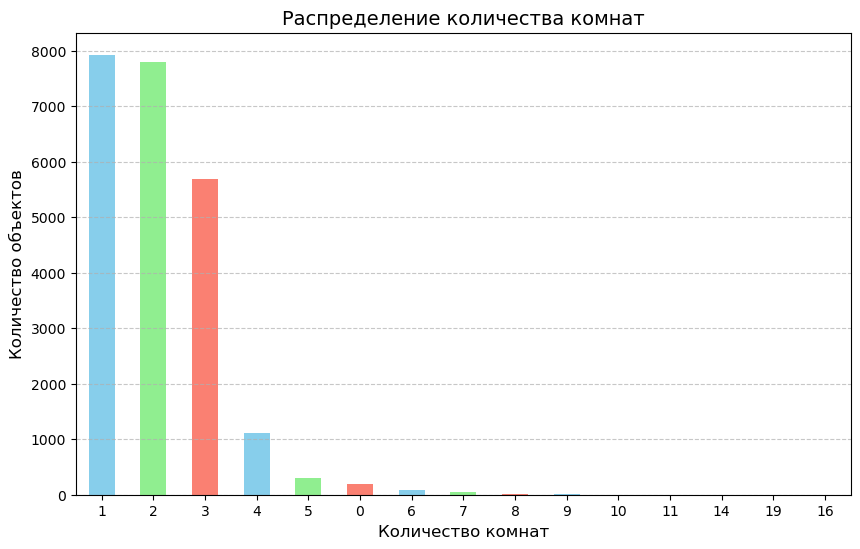

In [72]:
# Подсчет количества объектов по типам этажа
floor_counts = data['rooms'].value_counts()

# Создание столбчатой диаграммы
plt.figure(figsize=(10, 6))
floor_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])

# Настройка оформления
plt.title('Распределение количества комнат', fontsize=14)
plt.xlabel('Количество комнат', fontsize=12)
plt.ylabel('Количество объектов', fontsize=12)
plt.xticks(rotation=0)  # Горизонтальные подписи
plt.grid(axis='y', linestyle='--', alpha=0.7)

##### По гистограмме количества комнат можно сказать, что большинство квартир имеют от 1 до 3 комнат. График кососеммитричен и сосредоточен слева. Также есть редкие значения: больше 4 комнат. Это элитное жилье премиум-класса.

Text(0, 0.5, 'Количество объектов')

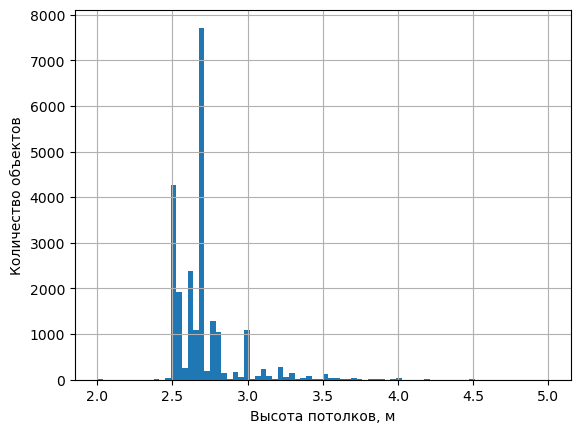

In [73]:
data['ceiling_height'].hist(bins=80, range=(2,5))
plt.xlabel('Высота потолков, м')
plt.ylabel('Количество объектов')

##### По гистограмме высоты потолков объектов можно сказать, что большинство квартир имеют потолки от 2.5 до 3 метров. График кососеммитричен и сосредоточен слева. Также есть редкие значения: больше 3.5 метров. Это элитное жилье премиум-класса с уникальной планировкой.

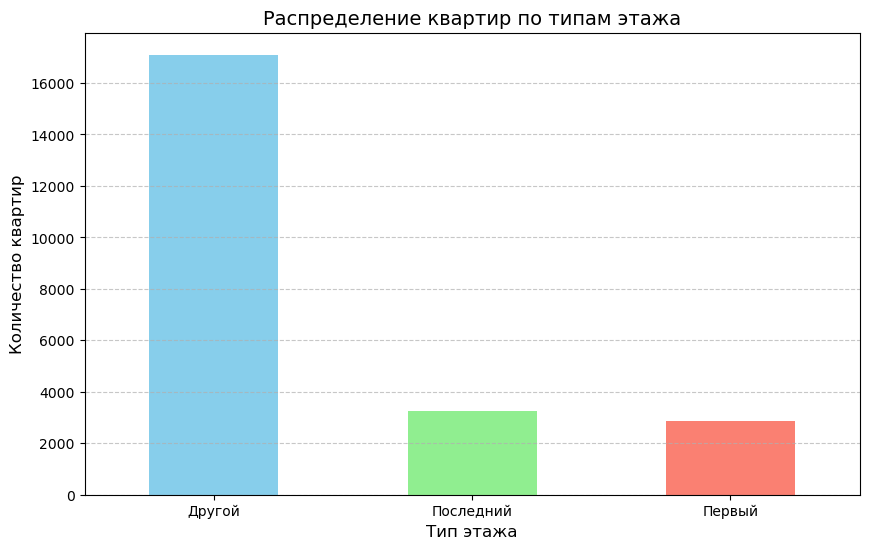

In [74]:
# Подсчет количества объектов по типам этажа
floor_counts = data['floor_type'].value_counts()

# Создание столбчатой диаграммы
plt.figure(figsize=(10, 6))
floor_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])

# Настройка оформления
plt.title('Распределение квартир по типам этажа', fontsize=14)
plt.xlabel('Тип этажа', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.xticks(rotation=0)  # Горизонтальные подписи
plt.grid(axis='y', linestyle='--', alpha=0.7)

##### По гистограмме типов этажей объектов можно сказать, что большинство объектов расположены на промежуточных этажа, это логично, учитывая, что большинство объектов недвижимости - многоэтажки.

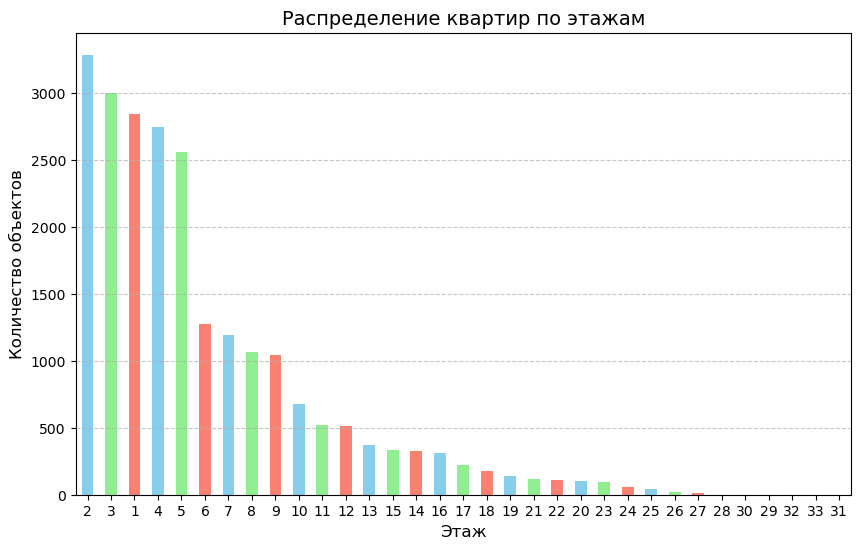

In [75]:
# Подсчет количества объектов по типам этажа
floor_counts = data['floor'].value_counts()

# Создание столбчатой диаграммы
plt.figure(figsize=(10, 6))
floor_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])

# Настройка оформления
plt.title('Распределение квартир по этажам', fontsize=14)
plt.xlabel('Этаж', fontsize=12)
plt.ylabel('Количество объектов', fontsize=12)
plt.xticks(rotation=0)  # Горизонтальные подписи
plt.grid(axis='y', linestyle='--', alpha=0.7)

##### По гистограмме этажей объектов можно сказать, что большинство объектов расположены на этажах от 2 до 5, это логично, учитывая, что большинство объектов недвижимости - многоэтажки. Интересно рассмотреть впадины. Изучив строительные нормативные акты, предполагаем, что это связано со строительными норматимвными актами.

Text(0, 0.5, 'Количество объектов')

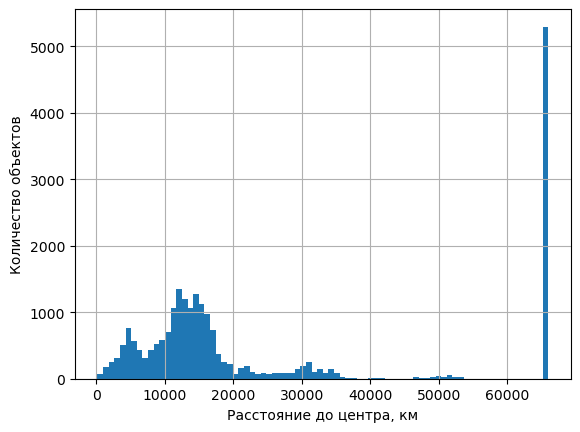

In [76]:
data['cityCenters_nearest'].hist(bins=80)
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Количество объектов')

##### По гистограмме удаления объектов  от центра можно сказать, что большинство объектов расположены на расстоянии от 5 до 20 км. Также есть большое количество объектов, расположенных далеко от центра. По Ленинградской области таких объектов больше пяти тысяч. 

Text(0, 0.5, 'Количество объектов')

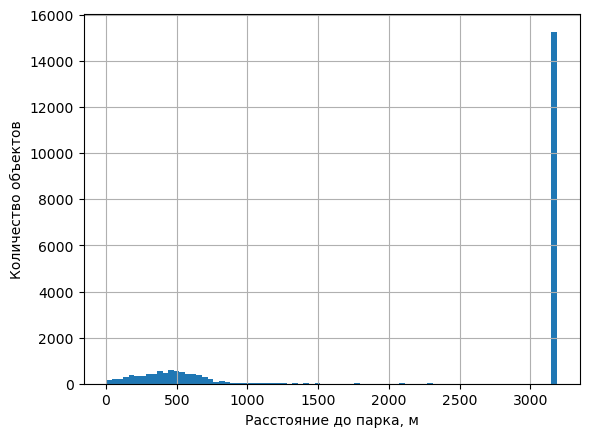

In [77]:
data['parks_nearest'].hist(bins=80)
plt.xlabel('Расстояние до парка, м')
plt.ylabel('Количество объектов')

##### По гистограмме удаления объектов от ближайшего парка можно сказать, что большинство объектов расположены на расстоянии более 3км от ближайшего парка. Это означает, что рядом с большинством обхектов парки находятся довольно далеко. Таких позиций более больше 15 тыс. Остальные обекты расположены от ближайшего парка в радиусе от 0 до 1 км.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Этот раздел выполнен качественно
</div>

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Отсутствует шаг 4.1 (по каждому пункту построить гистограмму и описать её). Добавь, пожалуйста

<div class="alert alert-info"> <b>Комментарии студента:</b> Доделал шаг 4.1: построены гистограммы и заключены выводы по каждому параметру.</div>

### Проведите исследовательский анализ данных

#### Изучим, как быстро продавались квартиры, опирасясь на столбец 'days_exposition'

Text(0.5, 1.0, 'Распределение продаж по сроку размещения')

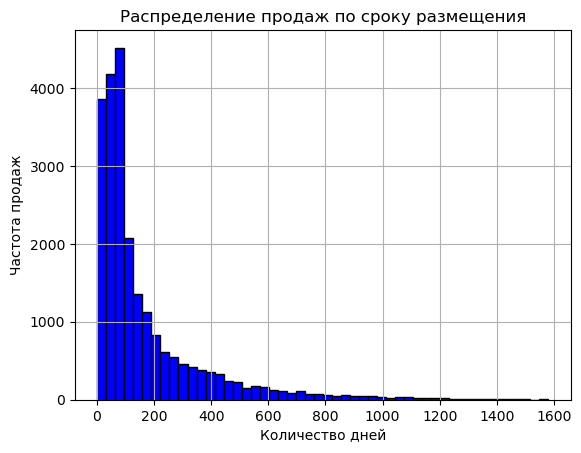

In [78]:
data['days_exposition'].hist(bins=50, color='blue', edgecolor='black')
plt.xlabel('Количество дней')
plt.ylabel('Частота продаж')
plt.title('Распределение продаж по сроку размещения')


In [79]:
exposition_median = data['days_exposition'].median()
exposition_median

95.0

In [80]:
exposition_mean = data['days_exposition'].mean()
exposition_mean

169.90670981661273

##### Большинство продаж наступает в течение 95 дней с момента размещения. Медиана дает в нашем случае объективный результат, на который не влияют необычно большие значения. Чтобы посмотреть интервал нормальных значений построим диаграмму размаха.

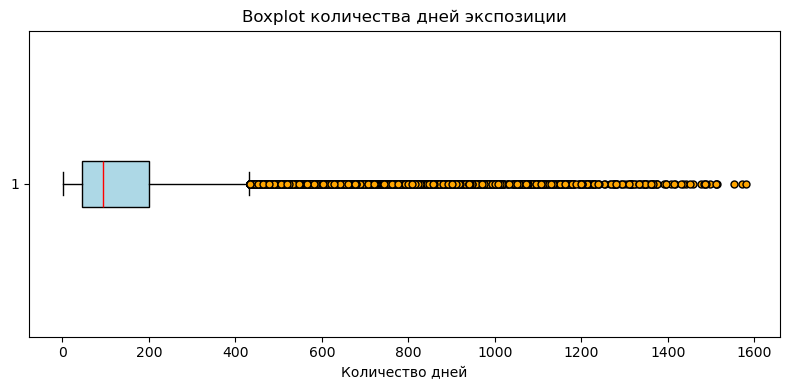

In [81]:
# Построим boxplot для days_exposition
plt.figure(figsize=(8, 4))
plt.boxplot(data['days_exposition'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
plt.title('Boxplot количества дней экспозиции')
plt.xlabel('Количество дней')
plt.tight_layout()
plt.show()


In [82]:
data['days_exposition'].describe()

count    23175.000000
mean       169.906710
std        207.049435
min          1.000000
25%         45.000000
50%         95.000000
75%        200.000000
max       1580.000000
Name: days_exposition, dtype: float64

##### По итогам небольшого анализа можно сказать, что большинство квартир продает в срок между 45 и 200 днями. Выражения, выбивающиеся из наших данных - необычные, но реальные. Продажи до 45 дней можем считать быстрыми, а больше 200 - медленными.

#### Изучим, какие параметры больше всего влияют на цену недвижимости

#### В процессе анализа воспользуемся степенями корреляции, соглсано таблице:

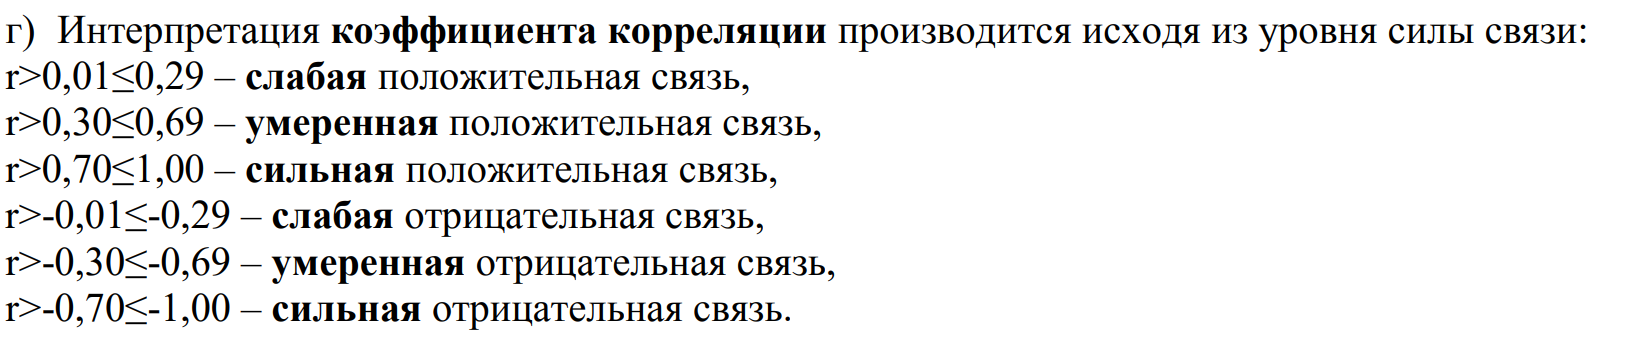

##### Посмотрим как значения столбца 'last_price' с ценами на недвижимость коррелирует с остальными

In [83]:
numeric_data = data.select_dtypes(include=['number'])  # Оставляем только числовые столбцы
correlations = numeric_data.corr()['last_price'].sort_values(ascending=False)
print(correlations)

last_price                1.000000
total_area                0.784005
cost_per_sqm              0.681649
living_area               0.668404
kitchen_area              0.626211
rooms                     0.513810
ceiling_height            0.435304
ponds_around3000          0.291182
parks_around3000          0.286116
total_images              0.148768
days_exposition           0.091237
floor                     0.049545
floors_total              0.030810
month                     0.004109
week_day                 -0.015735
year                     -0.042567
ponds_nearest            -0.259186
parks_nearest            -0.268958
airports_nearest         -0.299361
cityCenters_nearest_km   -0.400850
cityCenters_nearest      -0.400850
Name: last_price, dtype: float64


##### Исследуем корреляцию общей площади квартиры ('total_area') и цены квартиры ('last_price').
##### Построим график scatter()

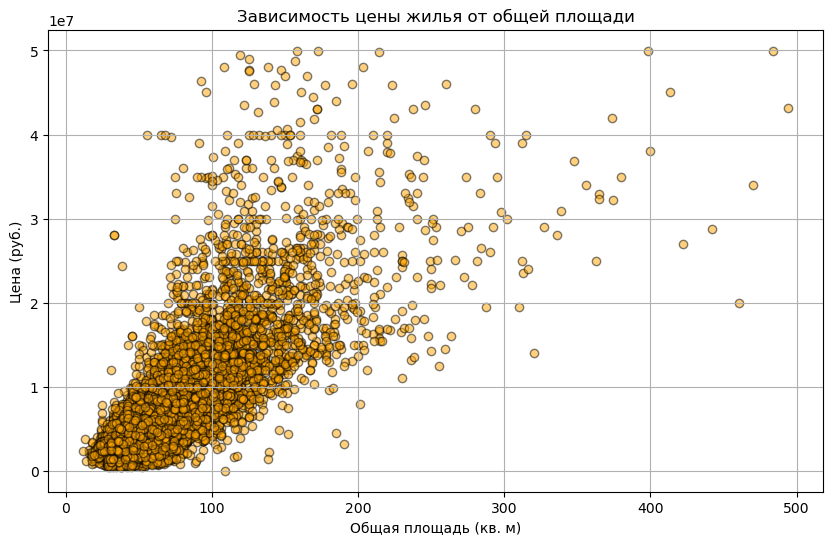

In [84]:
plt.figure(figsize=(10, 6))
plt.scatter(data['total_area'], data['last_price'], alpha=0.5, color='orange', edgecolors='k')
plt.title('Зависимость цены жилья от общей площади')
plt.xlabel('Общая площадь (кв. м)')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### Коэффициент корреляции 0.78 говорит о сильной положительной связи. По графику видно линейную корреляцию, которая особо заметна в диапазоне площади квартир: до 200 кв.м и ценой: до 30 млн рублей. 
##### Далее корреляция уменьшается и зависимость следовательно тоже. Поэтоу про необычне значения (аномалии сказать что-то трудно).

#### Исследуем корреляцию между жилой площадью ('living_area') и ценой квартиры ('last_price').
#### Построим график scatter().

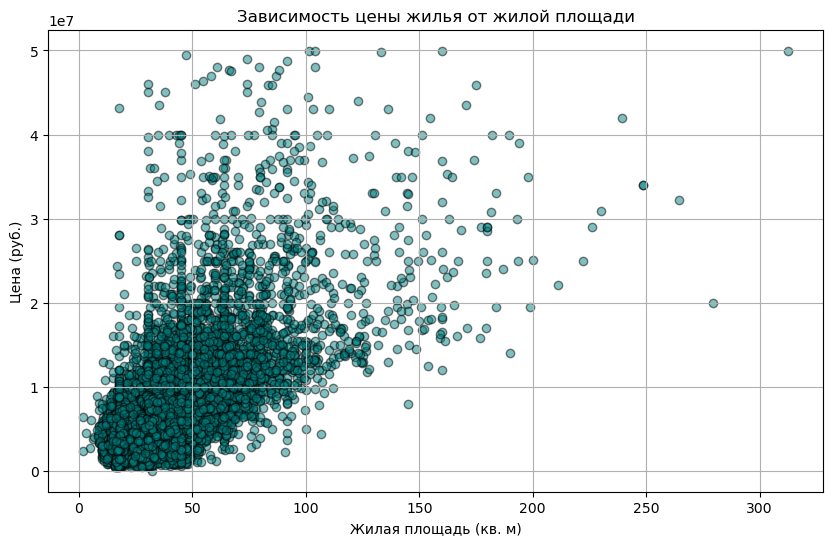

In [85]:
plt.figure(figsize=(10, 6))
plt.scatter(data['living_area'], data['last_price'], alpha=0.5, color='teal', edgecolors='k')
plt.title('Зависимость цены жилья от жилой площади')
plt.xlabel('Жилая площадь (кв. м)')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### Картина получается аналогичной зависимости от общей площади. Правда, коэффициент корреляции чуть меньше: 0.68 говорит о положительной умеренной корреляции.

#### Посмотрим, как коррелируют площадь кухни ('kitchen_area') и цена жилья ('last_price'). 
#### Построим график scatter(). 

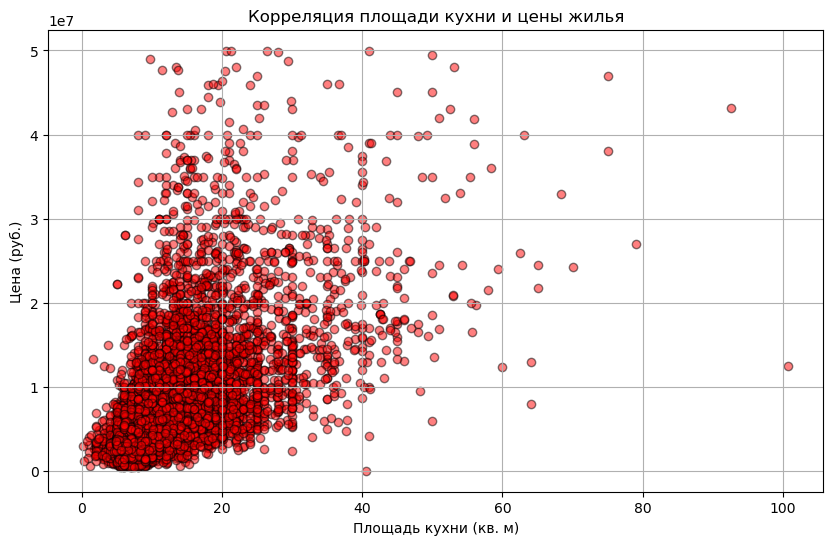

In [86]:
plt.figure(figsize=(10, 6))
plt.scatter(data['kitchen_area'], data['last_price'], alpha=0.5, color='red', edgecolors='k')
plt.title('Корреляция площади кухни и цены жилья')
plt.xlabel('Площадь кухни (кв. м)')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### Коэффициент корреляции 0.62 говорит о положительной умеренной связи. На графике корреляции отметим, что она положительна и линейна. Является наибольшей в диапазоне площади кухни: от 5 до 30 кв.м и стоимости квартиры: от 5 до 20 млн рублей.

#### Исследуем корреляцию между количеством комнат ('rooms') и ценой квартиры ('last_price').
#### Построим график scatter()

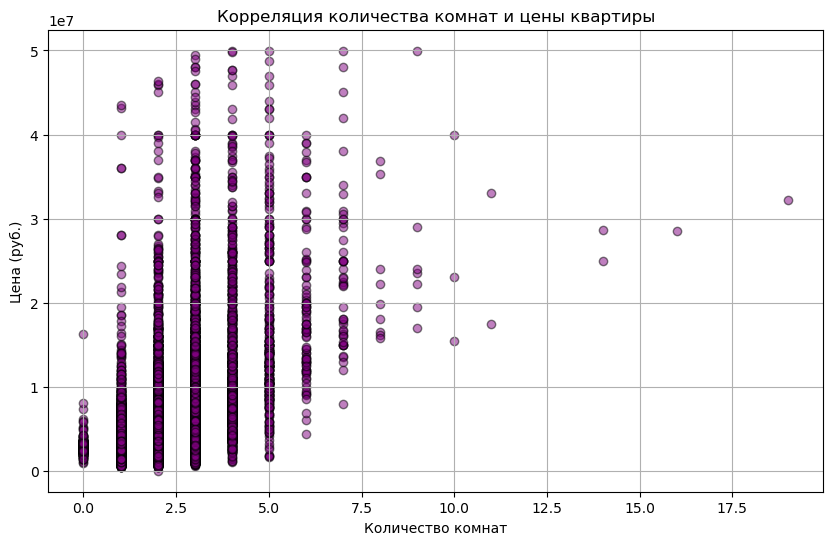

In [87]:
plt.figure(figsize=(10, 6))
plt.scatter(data['rooms'], data['last_price'], alpha=0.5, color='purple', edgecolors='k')
plt.title('Корреляция количества комнат и цены квартиры')
plt.xlabel('Количество комнат')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### По значению коэффициента корреляции, равного 0,51 можем сделать вывод, что корреляция умеренная и положительная. На графике установить вид зависимости нет возможности. 

#### Исследуем корреляцию между типом этажа ('floor_type') и ценой квартиры ('last_price').
#### Построим график scatter()

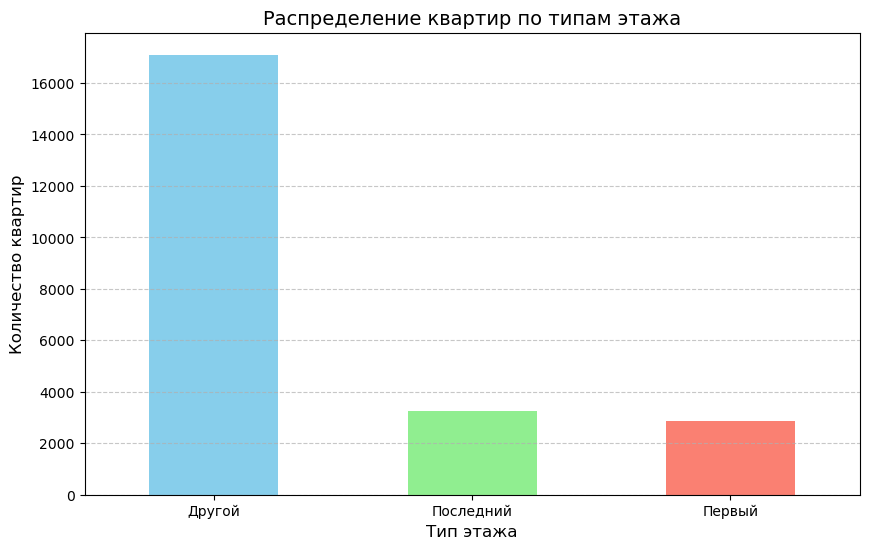

In [88]:
# Подсчет количества объектов по типам этажа
floor_counts = data['floor_type'].value_counts()

# Создание столбчатой диаграммы
plt.figure(figsize=(10, 6))
floor_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])

# Настройка оформления
plt.title('Распределение квартир по типам этажа', fontsize=14)
plt.xlabel('Тип этажа', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.xticks(rotation=0)  # Горизонтальные подписи
plt.grid(axis='y', linestyle='--', alpha=0.7)

##### Коэффициент корреляции номером этажа и ценой равен 0.05, что говорит о слабой положительной корреляции. На графике видно, что квартиры на первом этаже стоят меньше остальных.

#### Исследуем корреляцию между датой размещения и ценой квартиры. Построим график scatter()
##### Начнем со дня недели. 

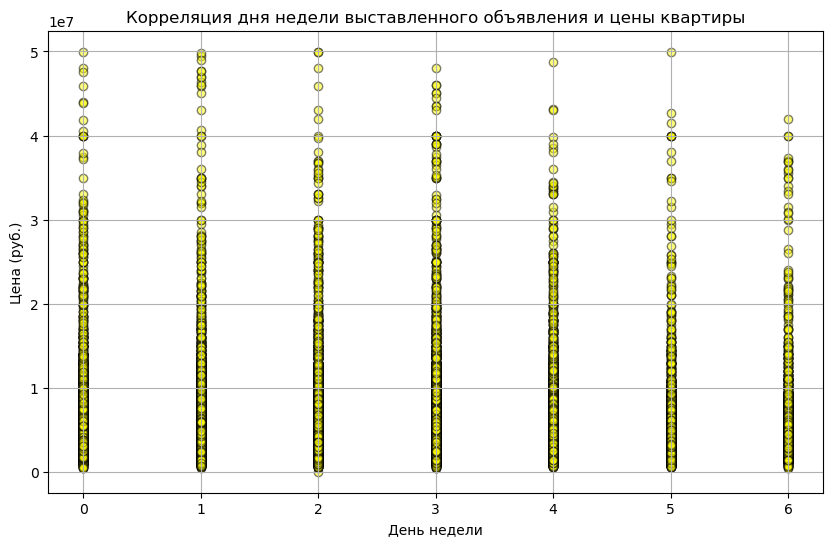

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(data['week_day'], data['last_price'], alpha=0.5, color='yellow', edgecolors='k')
plt.title('Корреляция дня недели выставленного объявления и цены квартиры')
plt.xlabel('День недели')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### Коэффициент корреляции между днем недели и ценой равен -0.15, что говорит о слабой отрицательной корреляции. На графике едва видно, то квартиры, выставленные в воскресенье, продавались дешевле.

##### Посмотрим корреляцию между месяцем выставления на продажу и конечной ценой 

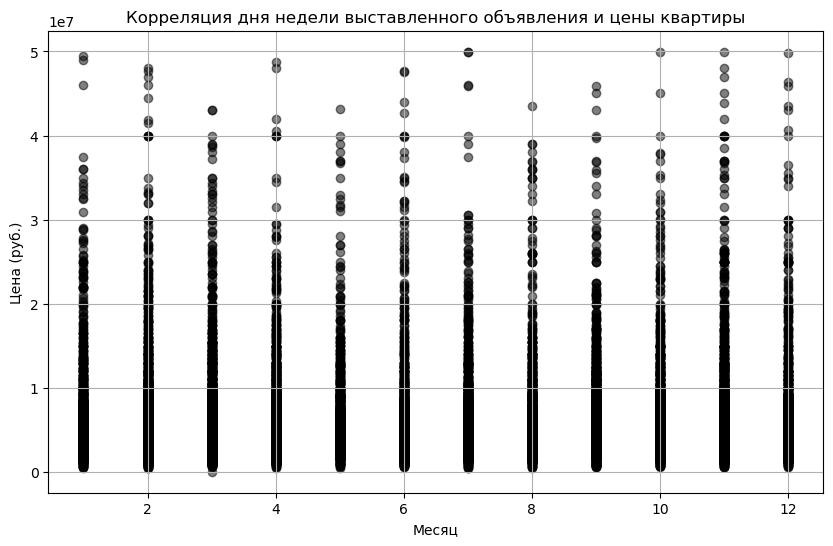

In [90]:
plt.figure(figsize=(10, 6))
plt.scatter(data['month'], data['last_price'], alpha=0.5, color='black', edgecolors='black')
plt.title('Корреляция дня недели выставленного объявления и цены квартиры')
plt.xlabel('Месяц')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### Коэффициент корреляции 0.04 говорит о слабой положительной корреляции, близкой к нулю. На графике установить какую-либо зависимость не удается.

##### Посмотрим корреляцию между годом выставления на продажу и конечной ценой 

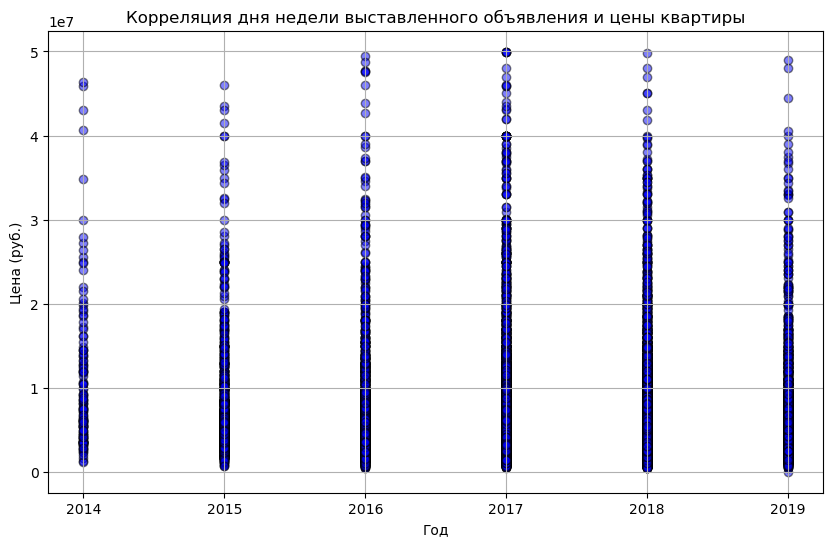

In [91]:
plt.figure(figsize=(10, 6))
plt.scatter(data['year'], data['last_price'], alpha=0.5, color='blue', edgecolors='k')
plt.title('Корреляция дня недели выставленного объявления и цены квартиры')
plt.xlabel('Год')
plt.ylabel('Цена (руб.)')
plt.grid(True)
plt.show()

##### Коэффициент корреляции -0,042 говорит о слабой отрицательной корреляции. По графику не удается установить вид зависимости.

#### Посчитаем среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений.

In [92]:
data['cityCenters_nearest_km'] = data['cityCenters_nearest_km'].astype(int) #сделаем количество километров целым значением

In [93]:
# Шаг 1: Найдём топ-10 городов по количеству объявлений
top_10_localities = data['locality_name'].value_counts().head(10).index

# Шаг 2: Отфильтруем данные
filtered_data = data[data['locality_name'].isin(top_10_localities)]
filtered_data


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,cost_per_sqm,week_day,month,year,floor_type,cityCenters_nearest_km
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.0,8,False,...,482.0,2.0,755.0,95,120370.370370,3,3,2019,Другой,16
1,7,3350000.0,40.40,2018-12-04,1,2.63,11,18.6,1,False,...,3190.0,0.0,1344.0,81,82920.792079,1,12,2018,Первый,18
2,10,5196000.0,56.00,2015-08-20,2,2.70,5,34.3,4,False,...,90.0,2.0,574.0,558,92785.714286,3,8,2015,Другой,13
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.0,13,False,...,112.0,1.0,48.0,121,100000.000000,1,6,2018,Другой,8
6,6,3700000.0,37.30,2017-11-02,1,2.64,26,10.6,6,False,...,3190.0,0.0,1344.0,155,99195.710456,3,11,2017,Другой,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23689,13,3550000.0,35.30,2018-02-28,1,2.86,15,16.3,4,False,...,353.0,2.0,652.0,29,100566.572238,2,2,2018,Другой,16
23690,3,5500000.0,52.00,2018-07-19,2,2.70,5,31.0,2,False,...,300.0,0.0,1344.0,15,105769.230769,3,7,2018,Другой,6
23691,11,9470000.0,72.90,2016-10-13,2,2.75,25,40.3,7,False,...,3190.0,1.0,806.0,519,129903.978052,3,10,2016,Другой,4
23694,9,9700000.0,133.81,2017-03-21,3,3.70,5,73.3,3,False,...,796.0,3.0,381.0,95,72490.845228,1,3,2017,Другой,4


In [94]:
# Шаг 3: Построим сводную таблицу
summary = pd.pivot_table(
    data=filtered_data,
    index='locality_name',
    values='cost_per_sqm',
    aggfunc=['median', 'mean']
)

# Упростим названия колонок
summary.columns = ['median_cost_per_sqm', 'mean_cost_per_sqm']
summary = summary.reset_index()

# Сортировка по медианной стоимости
summary = summary.sort_values(by='median_cost_per_sqm', ascending=False).round(1)

summary

,locality_name,median_cost_per_sqm,mean_cost_per_sqm
5,Санкт-Петербург,104540.3,112124.2
4,Пушкин,100000.0,103125.8
6,деревня Кудрово,91860.5,92473.5
8,посёлок Парголово,91642.9,90175.9
7,посёлок Мурино,85714.3,85629.7
9,посёлок Шушары,76829.3,78551.3
3,Колпино,74723.7,75424.6
2,Гатчина,67860.6,68757.7
0,Всеволожск,65789.5,68723.9
1,Выборг,58158.3,58141.9


In [95]:
min_cost_per_sqm_median = summary['median_cost_per_sqm'].min() #минимальная медианная стоимость за квадратный метр
min_cost_per_sqm_mean = summary['mean_cost_per_sqm'].min() #минимальная средняя стоимость за квадратный метр

max_cost_per_sqm_median = summary['median_cost_per_sqm'].max() #максимальная медианная стоимость за квадратный метр
max_cost_per_sqm_mean = summary['mean_cost_per_sqm'].max() #максимальная средняя стоимость за квадратный метр

#min_cost_per_sqm_median
#min_cost_per_sqm_mean
#max_cost_per_sqm_median
#max_cost_per_sqm_mean

##### Наименьшая стоимость жилья за квадратный метр - в Выборге

In [96]:
min_summary = summary[summary['median_cost_per_sqm'] == min_cost_per_sqm_median]
min_summary


,locality_name,median_cost_per_sqm,mean_cost_per_sqm
1,Выборг,58158.3,58141.9


##### Максимальная стоимость жилья за квадратный метр - в Санкт-Петерберге

In [97]:
max_summary = summary[summary['median_cost_per_sqm'] == max_cost_per_sqm_median]
max_summary

,locality_name,median_cost_per_sqm,mean_cost_per_sqm
5,Санкт-Петербург,104540.3,112124.2


#### Исследуем, как изменяется стоимость жилья на разном расстоянии от центра

In [98]:
spb_data = data.loc[data['locality_name'] == 'Санкт-Петербург']
spb_data_pivot = spb_data.pivot_table(index='cityCenters_nearest_km',
                                      values='last_price',
                                      aggfunc='median')
spb_data_pivot

,last_price
cityCenters_nearest_km,
0,11100000.0
1,10325000.0
2,9350000.0
3,8500000.0
4,9700000.0
5,8750000.0
6,7700000.0
7,7350000.0
8,6500000.0


##### Построим график plot() по найденным данным 

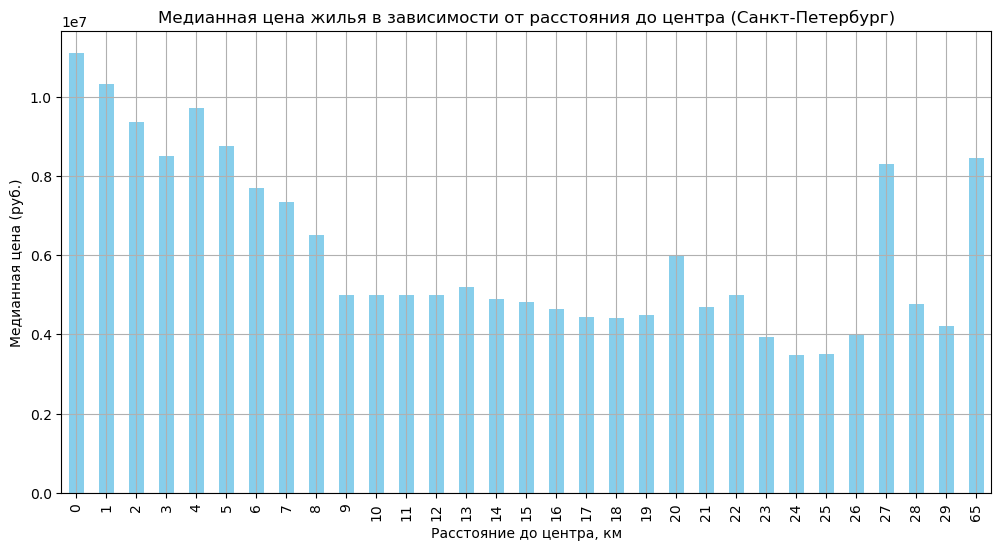

In [99]:
# Строим график изменения медианной цены от расстояния до центра
spb_data_pivot.plot(kind='bar', figsize=(12, 6), legend=False, color='skyblue')
plt.title('Медианная цена жилья в зависимости от расстояния до центра (Санкт-Петербург)')
plt.xlabel('Расстояние до центра, км')
plt.ylabel('Медианная цена (руб.)')
plt.grid(True)
plt.show()

#### Рассмотрим график распределения цены от расстояния до центра. Заметна наибольшая цена в самом центре: в радиусе 1 км. Далее цена снижается и график становится более равномерным в радиусе 9 км от центра. Там медианное значение цен равно 5 млн рублей. Стабильный график цен наблюдается в радиусе от 9 до 19 км включительно. На 20 и более километрах от центра видим резкие перепады цен. Они объясняются наличием дорогих загородных домов и коттеджей.

### Напишите общий вывод

## 🧠 Итоговый анализ от тим-лида команды Яндекс.Недвижимости

Команда аналитиков Яндекса провела масштабное исследование пользовательских и картографических данных, собранных в рамках платформы Яндекс.Недвижимость. Цель — выявить ключевые закономерности, влияющие на стоимость жилья, и подготовить основу для внедрения автоматической системы оценки и фильтрации предложений.

---

### 🔍 Этап 1: Подготовка и очистка данных

- Выполнена качественная предобработка:
  - Пропущенные значения логично заменены.
  - Типы данных приведены к нужному формату.
  - Аномалии удалены (например, потолки > 5 м, цена > 50 млн руб.).
  - Устранены дубликаты в названиях населённых пунктов.

- Добавлены новые признаки:
  - `cost_per_sqm` — цена за кв. м;
  - день, месяц, год публикации;
  - тип этажа (первый / последний / другой);
  - расстояние до центра города в км.

---

### ⏱ Этап 2: Анализ времени экспозиции

- Медианное время продажи — **95 дней**.
- Быстрая продажа: до **45 дней**, долгая — свыше **200**.
- Использование медианы предпочтительно из-за смещённости данных.

---

### 📊 Этап 3: Факторы, влияющие на цену

| Параметр              | Коэффициент | Вывод                                   |
|-----------------------|-------------|------------------------------------------|
| Общая площадь         | ≈ 0.78      | Сильная положительная зависимость        |
| Жилая площадь         | ≈ 0.68      | Умеренно сильная                         |
| Площадь кухни         | ≈ 0.62      | Умеренная                                |
| Количество комнат     | ≈ 0.51      | Умеренная                                |
| Тип этажа             | ≈ 0.05      | Слабая, но первый этаж дешевле           |
| День недели           | ≈ -0.15     | Незначительная, отрицательная корреляция |
| Месяц/год публикации  | ≈ ~0.04     | Зависимость практически отсутствует      |

> Вывод: физические параметры влияют на цену значительно больше, чем временные.

---

### 🌍 Этап 4: География и ценообразование

- Санкт-Петербург — лидер по цене за квадратный метр.
- Выборг — самый доступный город среди популярных.
- В радиусе 1 км от центра СПб — максимальные медианные цены.
- После 9 км — выравнивание, после 20 км — ценовые колебания (загородная элитка).

---

### 🧩 Заключение

> Проведённый анализ подтверждает: пользовательские и пространственные признаки позволяют точно оценивать рыночную стоимость объектов.  
> Результаты используются для улучшения:
>
> - системы **ранжирования** объявлений;
> - **оценки справедливой стоимости**;
> - выявления **аномалий** и потенциальных мошеннических предложений;
> - формирования **персонализированных рекомендаций**.

Развитие аналитической платформы Яндекс.Недвижимости продолжается, включая внедрение машинного обучения и предиктивной оценки.
